# Project 2 - TMA4300

## Problem 1

Suppose the joint density of U,Z up to a normalizing constant is given by

$$
f^*_{U,Z}(u,z) = \begin{cases}
1 & \text{for } 0 < u < e^{-z^2/2} \\
0 & \text{elsewhere}
\end{cases}
$$

### Part a) Deriving the full conditionals

**Full conditional of U given Z:**

Fix $Z = z$. Then $u$ must satisfy $0 < u < e^{-z^2/2}$, and the density is constant (= 1) on this interval.

$$U | Z = z \sim \text{Uniform}(0, e^{-z^2/2})$$

**Full conditional of Z given U:**

Fix $U = u$. Rearrange the constraint $u < e^{-z^2/2}$:
1. $\ln(u) < -z^2/2$
2. $-2\ln(u) > z^2$
3. $|z| < \sqrt{-2\ln(u)}$

The density is constant on this interval, so:

$$Z | U = u \sim \text{Uniform}\left(-\sqrt{-2\ln(u)}, \sqrt{-2\ln(u)}\right)$$

### Gibbs Sampler

Sampling directly from $f^*_{U,Z}(u,z)$ is difficult because the support region $\{(u,z) : 0 < u < e^{-z^2/2}\}$ has a complex shape. However, we derived that the full conditionals are simple uniform distributions:

- $U | Z \sim \text{Uniform}(0, e^{-z^2/2})$
- $Z | U \sim \text{Uniform}\left(-\sqrt{-2\ln(u)}, \sqrt{-2\ln(u)}\right)$

**Algorithm:**
1. Initialize $(U_0, Z_0)$
2. For $t = 1, 2, \ldots, n$:
   - Sample $U_t \sim \text{Uniform}(0, e^{-Z_{t-1}^2/2})$
   - Sample $Z_t \sim \text{Uniform}\left(-\sqrt{-2\ln(U_t)}, \sqrt{-2\ln(U_t)}\right)$
3. Return samples $(U_1, Z_1), (U_2, Z_2), \ldots, (U_n, Z_n)$

After sufficient iterations, these samples approximate draws from the joint distribution $f^*_{U,Z}$.

In [2]:
n <- 10000

U <- numeric(n)
Z <- numeric(n)

Z[1] <- 0
U[1] <- 0.5

for (t in 2:n) {
	#sample U|Z
	U[t] <- runif(1, min=0, max = exp(-Z[t-1]^2/2))

	bound <- sqrt(-2*log(U[t]))
	#sample Z|U
	Z[t] <- runif(1, min=-bound, max=bound)
}



### Part b) Marginal distribution of Z

To find the marginal distribution of $Z$, we integrate out $U$ from the joint density:

$$f_Z(z) = \int_0^{e^{-z^2/2}} 1 \, du = e^{-z^2/2}$$

This is the kernel of the standard normal distribution. Therefore:

$$Z \sim N(0, 1)$$

The Gibbs sampler is effectively a method for generating standard normal samples by introducing an auxiliary variable $U$.

### Part c) Correlation structure

We use the law of total covariance:
$$\text{Cov}(X, Y) = E[\text{Cov}(X, Y | W)] + \text{Cov}(E[X|W], E[Y|W])$$

Condition on $U_n$. The dependence structure is $Z_{n-1} \to U_n \to Z_n$.

1. Given $U_n$, $Z_n$ is sampled independently of $Z_{n-1}$, so $\text{Cov}(Z_{n-1}, Z_n | U_n) = 0$.

2. $E[Z_n | U_n] = 0$ since $Z_n | U_n \sim \text{Uniform}(-a, a)$ is symmetric around 0.

Therefore:
$$\text{Cov}(Z_{n-1}, Z_n) = E[0] + \text{Cov}(E[Z_{n-1}|U_n], 0) = 0$$

**Conclusion:** $Z_{n-1}$ and $Z_n$ are uncorrelated.

---

Again condition on $U_n$:

1. Given $U_n$, $Z_{n-1}^2$ and $Z_n^2$ are independent, so $\text{Cov}(Z_{n-1}^2, Z_n^2 | U_n) = 0$.

2. For the second term, we need $E[Z_n^2 | U_n]$ and $E[Z_{n-1}^2 | U_n]$.

For $Z_n | U_n \sim \text{Uniform}(-a, a)$ where $a = \sqrt{-2\ln(U_n)}$:
$$E[Z_n^2 | U_n] = \text{Var}(Z_n | U_n) + E[Z_n | U_n]^2 = \frac{a^2}{3} + 0 = \frac{-2\ln(U_n)}{3}$$

For $Z_{n-1} | U_n$, we use Bayes' rule. At stationarity, $Z_{n-1} \sim N(0,1)$ and $U_n | Z_{n-1} \sim \text{Uniform}(0, e^{-Z_{n-1}^2/2})$:
$$f(Z_{n-1} | U_n) \propto f(U_n | Z_{n-1}) f(Z_{n-1}) \propto \frac{1}{e^{-Z_{n-1}^2/2}} \cdot e^{-Z_{n-1}^2/2} \cdot I(U_n < e^{-Z_{n-1}^2/2}) \propto I(|Z_{n-1}| < \sqrt{-2\ln(U_n)})$$

So $Z_{n-1} | U_n \sim \text{Uniform}(-\sqrt{-2\ln(U_n)}, \sqrt{-2\ln(U_n)})$, the same distribution as $Z_n | U_n$!

Therefore:
$$E[Z_{n-1}^2 | U_n] = E[Z_n^2 | U_n] = \frac{-2\ln(U_n)}{3}$$

Let $W = \frac{-2\ln(U_n)}{3}$. Then:
$$\text{Cov}(E[Z_{n-1}^2|U_n], E[Z_n^2|U_n]) = \text{Cov}(W, W) = \text{Var}(W) > 0$$

**Conclusion:** $Z_{n-1}^2$ and $Z_n^2$ **are correlated** (positively).

## Problem 2

### Part a) Maximum likelihood estimates

We fit the random intercept model using `glmmTMB` to obtain MLE estimates of $\mu$, $1/\tau$ (residual variance) and $1/\nu$ (random intercept variance) for later comparison with our Gibbs sampler results.

In [3]:
load(url("https://www.math.ntnu.no/emner/TMA4300/2026v/random-intercept-data.RData"))
library(glmmTMB)
mod <- glmmTMB(y ~ (1|i), data=data)
summary(mod)

Warning message:
"package 'glmmTMB' was built under R version 4.5.2"


 Family: gaussian  ( identity )
Formula:          y ~ (1 | i)
Data: data

      AIC       BIC    logLik -2*log(L)  df.resid 
    280.3     288.1    -137.2     274.3        97 

Random effects:

Conditional model:
 Groups   Name        Variance Std.Dev.
 i        (Intercept) 0.2301   0.4797  
 Residual             0.7560   0.8695  
Number of obs: 100, groups:  i, 20

Dispersion estimate for gaussian family (sigma^2): 0.756 

Conditional model:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  10.1888     0.1381   73.79   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

We see from the outputs that the MLEs are:
- $\hat{\mu} = 10.1888$
- $\hat{1/\tau} = 0.7560$
- $\hat{1/\nu} = 0.2301$

### Part b) Full conditional distributions

We want to derive the full conditional distributions of $\mu$, $\gamma_i$, $\tau$, and $\nu$ for use in a Gibbs sampler.

#### Step 1: The joint posterior

By Bayes' theorem:

$$\pi(\mu, \gamma_1, \ldots, \gamma_m, \tau, \nu \mid \mathbf{y}) = \frac{f(\mathbf{y} \mid \mu, \boldsymbol{\gamma}, \tau) \cdot \pi(\mu, \gamma_1, \ldots, \gamma_m, \tau, \nu)}{f(\mathbf{y})} \propto f(\mathbf{y} \mid \mu, \boldsymbol{\gamma}, \tau) \cdot \pi(\mu, \gamma_1, \ldots, \gamma_m, \tau, \nu)$$

The denominator $f(\mathbf{y})$ does not depend on the parameters, so we can drop it and work with proportionality.

The prior $\pi(\mu, \gamma_1, \ldots, \gamma_m, \tau, \nu)$ factors due to the independence structure given by the DAG. Using the chain rule and the conditional independence assumptions:

$$\pi(\mu, \gamma_1, \ldots, \gamma_m, \tau, \nu) = \pi(\mu) \cdot \pi(\tau) \cdot \pi(\nu) \cdot \pi(\gamma_1, \ldots, \gamma_m \mid \mu, \tau, \nu)$$

Since the $\gamma_i$'s only depend on $\nu$ (not on $\mu$ or $\tau$):

$$= \pi(\mu) \cdot \pi(\tau) \cdot \pi(\nu) \cdot \pi(\gamma_1, \ldots, \gamma_m \mid \nu)$$

And since the $\gamma_i$'s are conditionally independent given $\nu$:

$$= \pi(\mu) \cdot \pi(\tau) \cdot \pi(\nu) \cdot \prod_{i=1}^{m} f(\gamma_i \mid \nu)$$

Since $\pi(\mu) \propto 1$ (flat prior), it drops out. The full posterior is therefore:

$$\pi(\mu, \boldsymbol{\gamma}, \tau, \nu \mid \mathbf{y}) \propto \underbrace{\prod_{i=1}^{m}\prod_{j=1}^{n_i} f(y_{ij} \mid \mu, \gamma_i, \tau)}_{\text{likelihood}} \cdot \underbrace{\prod_{i=1}^{m} f(\gamma_i \mid \nu)}_{\text{prior on } \gamma_i\text{'s}} \cdot \underbrace{\pi(\tau) \cdot \pi(\nu)}_{\text{priors on } \tau, \nu}$$

#### Step 2: Writing out each density explicitly

From equation (5), $y_{ij} \mid \mu, \gamma_i, \tau \sim N(\mu + \gamma_i, \tau^{-1})$:

$$f(y_{ij} \mid \mu, \gamma_i, \tau) = \sqrt{\frac{\tau}{2\pi}} \exp\left(-\frac{\tau}{2}(y_{ij} - \mu - \gamma_i)^2\right)$$

From equation (3), $\gamma_i \mid \nu \sim N(0, \nu^{-1})$:

$$f(\gamma_i \mid \nu) = \sqrt{\frac{\nu}{2\pi}} \exp\left(-\frac{\nu}{2}\gamma_i^2\right)$$

From equation (4), $\tau \sim \Gamma(\alpha, \alpha)$ and $\nu \sim \Gamma(\alpha, \alpha)$:

$$\pi(\tau) = \frac{\alpha^\alpha}{\Gamma(\alpha)} \tau^{\alpha-1} \exp(-\alpha\tau), \qquad \pi(\nu) = \frac{\alpha^\alpha}{\Gamma(\alpha)} \nu^{\alpha-1} \exp(-\alpha\nu)$$

#### Step 3: The full joint posterior (substituted)

Substituting all densities into the joint posterior:

$$\pi(\mu, \boldsymbol{\gamma}, \tau, \nu \mid \mathbf{y}) \propto \prod_{i=1}^{m}\prod_{j=1}^{n_i} \tau^{1/2} \exp\left(-\frac{\tau}{2}(y_{ij} - \mu - \gamma_i)^2\right) \cdot \prod_{i=1}^{m} \nu^{1/2} \exp\left(-\frac{\nu}{2}\gamma_i^2\right) \cdot \tau^{\alpha-1} \exp(-\alpha\tau) \cdot \nu^{\alpha-1} \exp(-\alpha\nu)$$

where we have dropped all constant factors (powers of $2\pi$, $\alpha^\alpha / \Gamma(\alpha)$, etc.) since they do not depend on the parameters.

---

#### Full conditional 1: $\mu \mid \boldsymbol{\gamma}, \tau, \nu, \mathbf{y}$

Keep only terms involving $\mu$. The only factor containing $\mu$ is the likelihood:

$$\pi(\mu \mid \text{rest}) \propto \prod_{i=1}^{m}\prod_{j=1}^{n_i} \exp\left(-\frac{\tau}{2}(y_{ij} - \mu - \gamma_i)^2\right)$$

Combine the product of exponentials into a single exponential (product becomes sum in the exponent):

$$= \exp\left(-\frac{\tau}{2}\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2\right)$$

Expand the square inside the sum:

$$(y_{ij} - \mu - \gamma_i)^2 = y_{ij}^2 - 2y_{ij}(\mu + \gamma_i) + (\mu + \gamma_i)^2$$

Summing over all observations and dropping terms that do not involve $\mu$:

$$\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2 \;\overset{\mu}{\propto}\; n\mu^2 - 2\mu\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \gamma_i)$$

where $n = \sum_{i=1}^{m} n_i$ is the total number of observations.

Complete the square in $\mu$:

$$n\mu^2 - 2\mu\sum_{i}\sum_{j}(y_{ij} - \gamma_i) = n\left(\mu - \frac{\sum_{i}\sum_{j}(y_{ij} - \gamma_i)}{n}\right)^2 + \text{const}$$

Substituting back into the exponential, we recognize the kernel of a normal distribution:

$$\boxed{\mu \mid \boldsymbol{\gamma}, \tau, \nu, \mathbf{y} \sim N\left(\frac{\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \gamma_i)}{n}, \; \frac{1}{n\tau}\right)}$$

The mean is the average of all observations corrected for group effects, and the precision is $n\tau$.

---

#### Full conditional 2: $\gamma_i \mid \mu, \tau, \nu, \mathbf{y}$

Keep only terms involving $\gamma_i$. Two factors contain $\gamma_i$: the likelihood terms for group $i$, and the prior on $\gamma_i$:

$$\pi(\gamma_i \mid \text{rest}) \propto \exp\left(-\frac{\tau}{2}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2\right) \cdot \exp\left(-\frac{\nu}{2}\gamma_i^2\right)$$

Note: only the $n_i$ observations from group $i$ involve $\gamma_i$, so the double product collapses to a single sum over $j$.

Combine into a single exponential:

$$= \exp\left(-\frac{1}{2}\left(\tau\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2 + \nu\gamma_i^2\right)\right)$$

Expand the exponent:

$$\tau\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2 + \nu\gamma_i^2 = \tau\sum_{j=1}^{n_i}(y_{ij} - \mu)^2 - 2\tau\gamma_i\sum_{j=1}^{n_i}(y_{ij} - \mu) + \tau n_i \gamma_i^2 + \nu\gamma_i^2$$

Drop terms not involving $\gamma_i$ and collect:

$$\overset{\gamma_i}{\propto}\; (n_i\tau + \nu)\gamma_i^2 - 2\tau\gamma_i\sum_{j=1}^{n_i}(y_{ij} - \mu)$$

Complete the square in $\gamma_i$:

$$= (n_i\tau + \nu)\left(\gamma_i - \frac{\tau\sum_{j=1}^{n_i}(y_{ij} - \mu)}{n_i\tau + \nu}\right)^2 + \text{const}$$

We recognize the kernel of a normal distribution:

$$\boxed{\gamma_i \mid \mu, \tau, \nu, \mathbf{y} \sim N\left(\frac{\tau\sum_{j=1}^{n_i}(y_{ij} - \mu)}{n_i\tau + \nu}, \; \frac{1}{n_i\tau + \nu}\right)}$$

The mean is a weighted compromise between the group data (pulling toward $\bar{y}_i - \mu$) and the prior (pulling toward 0), with precision $n_i\tau + \nu$.

---

#### Full conditional 3: $\tau \mid \mu, \boldsymbol{\gamma}, \nu, \mathbf{y}$

Keep only terms involving $\tau$. These come from the likelihood and the prior on $\tau$:

$$\pi(\tau \mid \text{rest}) \propto \tau^{n/2} \cdot \exp\left(-\frac{\tau}{2}\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2\right) \cdot \tau^{\alpha-1} \cdot \exp(-\alpha\tau)$$

The $\tau^{n/2}$ comes from the product $\prod_{i}\prod_{j} \tau^{1/2} = \tau^{n/2}$.

Combine powers and exponentials:

$$= \tau^{n/2 + \alpha - 1} \cdot \exp\left(-\tau\left(\frac{1}{2}\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2 + \alpha\right)\right)$$

This is the kernel of a Gamma distribution:

$$\boxed{\tau \mid \mu, \boldsymbol{\gamma}, \nu, \mathbf{y} \sim \Gamma\left(\frac{n}{2} + \alpha, \; \frac{1}{2}\sum_{i=1}^{m}\sum_{j=1}^{n_i}(y_{ij} - \mu - \gamma_i)^2 + \alpha\right)}$$

---

#### Full conditional 4: $\nu \mid \mu, \boldsymbol{\gamma}, \tau, \mathbf{y}$

Keep only terms involving $\nu$. These come from the prior on $\gamma_i$'s and the prior on $\nu$:

$$\pi(\nu \mid \text{rest}) \propto \nu^{m/2} \cdot \exp\left(-\frac{\nu}{2}\sum_{i=1}^{m}\gamma_i^2\right) \cdot \nu^{\alpha-1} \cdot \exp(-\alpha\nu)$$

The $\nu^{m/2}$ comes from the product $\prod_{i=1}^{m} \nu^{1/2} = \nu^{m/2}$.

Combine:

$$= \nu^{m/2 + \alpha - 1} \cdot \exp\left(-\nu\left(\frac{1}{2}\sum_{i=1}^{m}\gamma_i^2 + \alpha\right)\right)$$

This is the kernel of a Gamma distribution:

$$\boxed{\nu \mid \mu, \boldsymbol{\gamma}, \tau, \mathbf{y} \sim \Gamma\left(\frac{m}{2} + \alpha, \; \frac{1}{2}\sum_{i=1}^{m}\gamma_i^2 + \alpha\right)}$$

Same structure as $\tau$, but with $m$ groups instead of $n$ observations, and $\gamma_i^2$ instead of residuals.

### Part c) Gibbs sampler implementation

We implement a Gibbs sampler that cycles through the four full conditionals derived in part b). Each iteration samples $\mu$, all $\gamma_i$'s, $\tau$, and $\nu$ in sequence. We store $\mu$, $1/\tau$, and $1/\nu$, along with the $\gamma_i$'s.

In [4]:

library(coda)

gibbs_sampler <- function(data, n_iter = 20000, alpha = 0.0001) {
  # Extract data
  y <- data$y
  groups <- data$i
  m <- length(unique(groups))         # number of groups (20)
  n <- length(y)                       # total observations (100)
  
  # Precompute: which observations belong to each group
  group_idx <- split(seq_along(y), groups)
  n_i <- sapply(group_idx, length)     # observations per group
  
  # Initialize parameters
  mu <- mean(y)
  gamma <- rep(0, m)
  tau <- 1
  nu <- 1
  
  # Storage matrix: mu, 1/tau, 1/nu, gamma_1, ..., gamma_m
  p <- 3 + m
  samples <- matrix(0, nrow = n_iter, ncol = p)
  col_names <- c("mu", "1/tau", "1/nu", paste0("gamma_", 1:m))
  colnames(samples) <- col_names
  
  for (t in 1:n_iter) {
    # --- Sample mu ---
    # mu | rest ~ N(mean, variance)
    # mean = sum(y_ij - gamma_i) / n,  variance = 1/(n*tau)
    sum_y_minus_gamma <- sum(y - gamma[groups])
    mu_mean <- sum_y_minus_gamma / n
    mu_var <- 1 / (n * tau)
    mu <- rnorm(1, mean = mu_mean, sd = sqrt(mu_var))
    
    # --- Sample each gamma_i ---
    for (k in 1:m) {
      idx <- group_idx[[k]]
      sum_y_minus_mu <- sum(y[idx] - mu)
      gamma_prec <- n_i[k] * tau + nu
      gamma_mean <- (tau * sum_y_minus_mu) / gamma_prec
      gamma_var <- 1 / gamma_prec
      gamma[k] <- rnorm(1, mean = gamma_mean, sd = sqrt(gamma_var))
    }
    
    # --- Sample tau ---
    # tau | rest ~ Gamma(shape, rate)
    resid <- y - mu - gamma[groups]
    tau_shape <- n / 2 + alpha
    tau_rate <- sum(resid^2) / 2 + alpha
    tau <- rgamma(1, shape = tau_shape, rate = tau_rate)
    
    # --- Sample nu ---
    # nu | rest ~ Gamma(shape, rate)
    nu_shape <- m / 2 + alpha
    nu_rate <- sum(gamma^2) / 2 + alpha
    nu <- rgamma(1, shape = nu_shape, rate = nu_rate)
    
    # Store samples
    samples[t, ] <- c(mu, 1/tau, 1/nu, gamma)
  }
  
  return(mcmc(samples))
}

# Run the Gibbs sampler
set.seed(42)
result <- gibbs_sampler(data, n_iter = 20000, alpha = 0.0001)

Warning message:
"package 'coda' was built under R version 4.5.2"


### Part d) Summary and trace plots

We apply `summary` to the `mcmc` object to compare posterior means with the MLEs from part a), and examine trace plots for convergence.

In [5]:
summary(result[, c("mu", "1/tau", "1/nu")])


Iterations = 1:20000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 20000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean     SD  Naive SE Time-series SE
mu    10.1907 0.1445 0.0010216       0.002216
1/tau  0.8012 0.1387 0.0009807       0.002871
1/nu   0.2464 0.1613 0.0011409       0.003866

2. Quantiles for each variable:

          2.5%     25%     50%     75%   97.5%
mu    9.903894 10.0980 10.1897 10.2819 10.4803
1/tau 0.573087  0.7035  0.7871  0.8820  1.1200
1/nu  0.008785  0.1374  0.2195  0.3236  0.6435


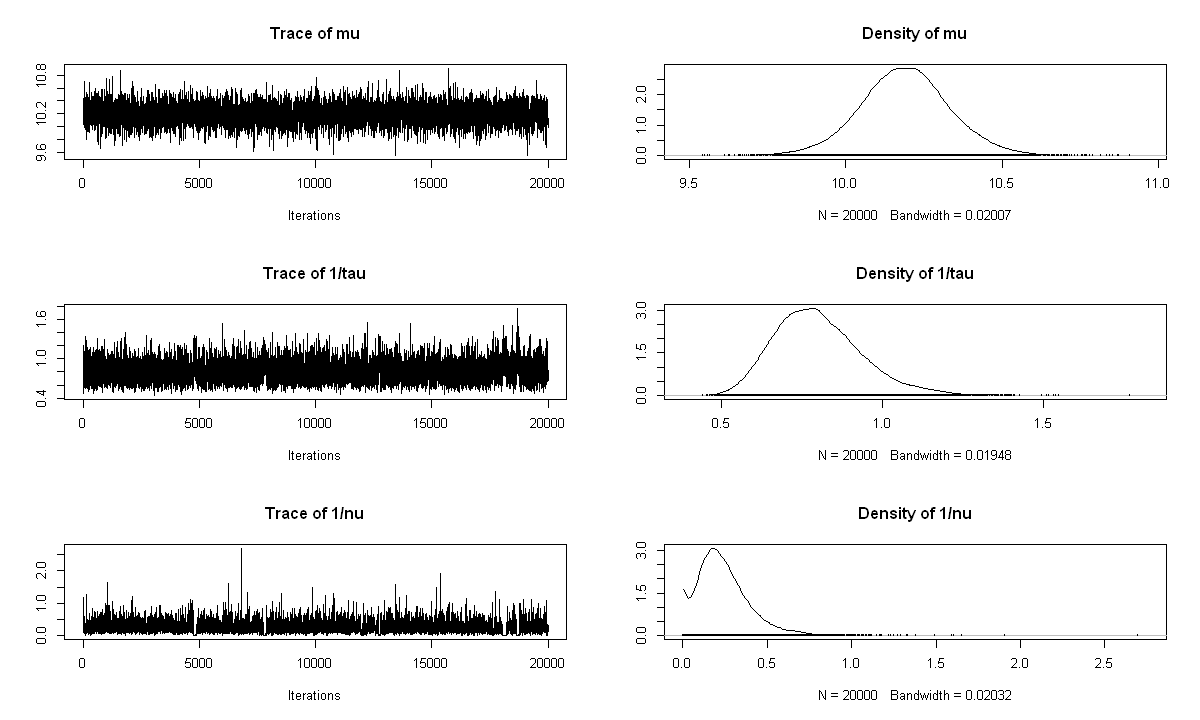

In [6]:
par(bg = "white")
plot(result[, c("mu", "1/tau", "1/nu")])

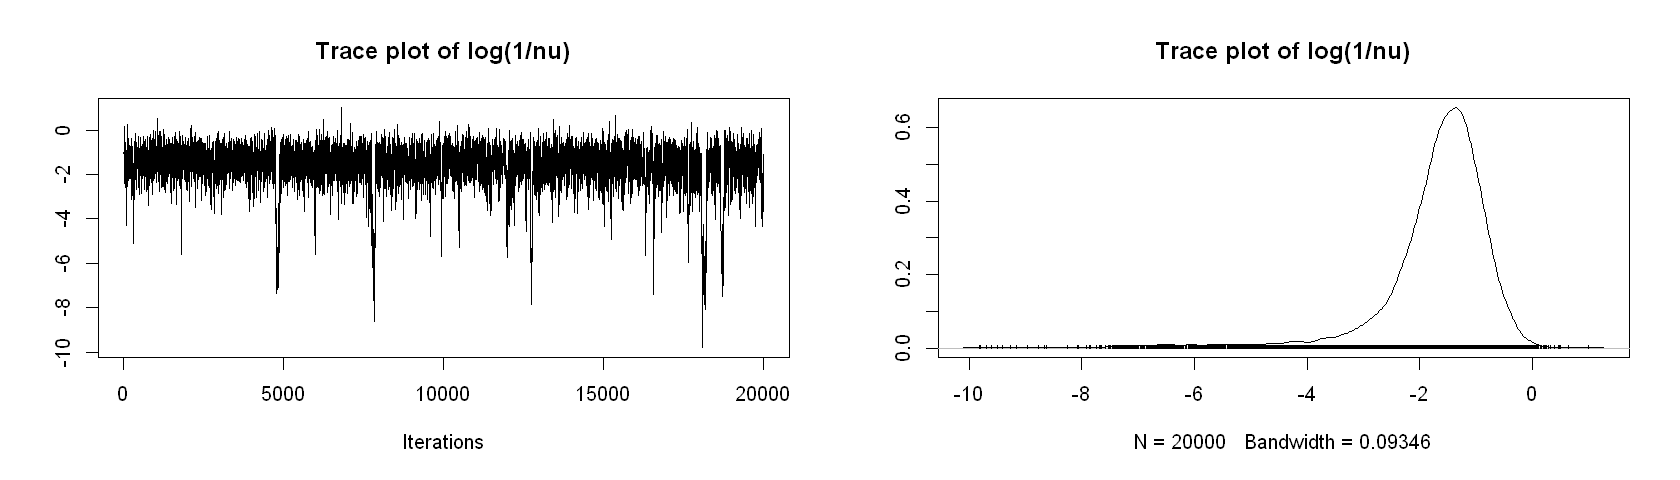

In [7]:
#sjekk log
par(bg = "white")
options(repr.plot.width = 14, repr.plot.height = 4)
plot(log(result[, "1/nu"]), main = "Trace plot of log(1/nu)")

**Comments**

The posterior means are close to the MLEs from part a), confirming that the Gibbs sampler is implemented correctly:

| Parameter | MLE | Posterior mean |
|-----------|-----|----------------|
| $\mu$ | 10.1888 | 10.1907 |
| $1/\tau$ | 0.7560 | 0.8012 |
| $1/\nu$ | 0.2301 | 0.2464 |

The trace plots for $\mu$ and $1/\tau$ show good mixing, stable patterns indicating convergence. Their posterior densities are roughly symmetric and well-behaved.

However, the trace plot and posterior density of $1/\nu$ shows problematic behavior:
- The posterior density is right-skewed, with most mass near zero and a long right tail.
- The trace plot shows the chain spending long periods near zero with occasional sharp spikes to values around 1–2, indicating poor mixing.
- The log-transform trace plot of $\log(1/\nu)$ makes this clearer, showing the chain drifting to very negative values (corresponding to $1/\nu \approx 0$).

This happens because the data contains only $m = 20$ groups, providing limited information about the between-group variance. The posterior is consistent with $1/\nu \approx 0$ (no random effects), making it difficult to estimate this parameter precisely.

### Part e) Prior distribution of the variance proportion

We define the proportion of variance attributed to the random intercept as:

$$p = \frac{\nu^{-1}}{\nu^{-1} + \tau^{-1}}$$

#### Deriving the prior distribution of $p$

First, simplify the expression by multiplying numerator and denominator by $\tau\nu$:

$$p = \frac{\nu^{-1}}{\nu^{-1} + \tau^{-1}} = \frac{\tau}{\tau + \nu}$$

From (4), we have $\tau \sim \Gamma(\alpha, \alpha)$ and $\nu \sim \Gamma(\alpha, \alpha)$ independently, both with the same shape and rate parameter.

By a well-known property of the Gamma distribution: if $X \sim \Gamma(a, b)$ and $Y \sim \Gamma(c, b)$ are independent, then $\frac{X}{X + Y} \sim \text{Beta}(a, c)$.

Here $X = \tau$ with shape $\alpha$ and $Y = \nu$ with shape $\alpha$, so:

$$\boxed{p = \frac{\tau}{\tau + \nu} \sim \text{Beta}(\alpha, \alpha)}$$

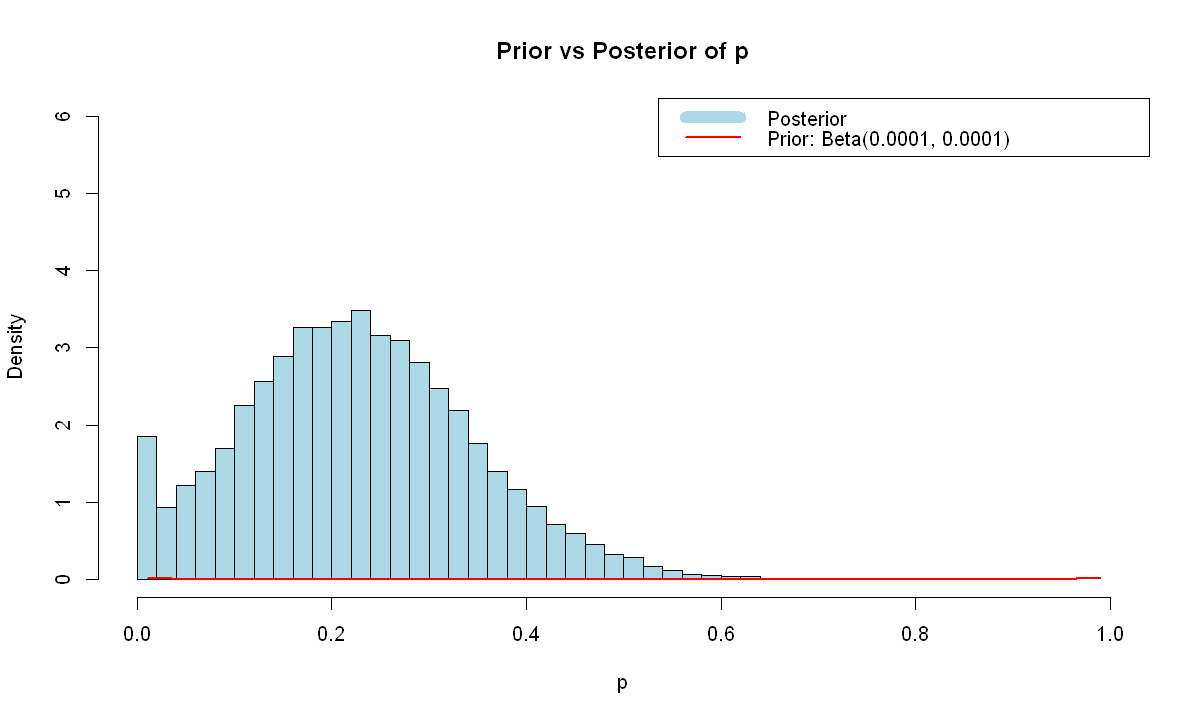

In [8]:
par(bg = "white")
options(repr.plot.width = 10, repr.plot.height = 6)

# Compute posterior samples of p from the stored 1/tau and 1/nu
inv_tau_samples <- result[, "1/tau"]
inv_nu_samples <- result[, "1/nu"]
p_post <- inv_nu_samples / (inv_nu_samples + inv_tau_samples)

# Plot posterior histogram
hist(p_post, breaks = 50, probability = TRUE, col = "lightblue",
     main = "Prior vs Posterior of p", xlab = "p", xlim = c(0, 1), ylim = c(0, 6))

# Overlay prior density: Beta(alpha, alpha) with alpha = 0.0001
x <- seq(0.01, 0.99, length.out = 500)
alpha <- 0.0001
lines(x, dbeta(x, alpha, alpha), col = "red", lwd = 2)

legend("topright", legend = c("Posterior", "Prior: Beta(0.0001, 0.0001)"),
       col = c("lightblue", "red"), lwd = c(10, 2))

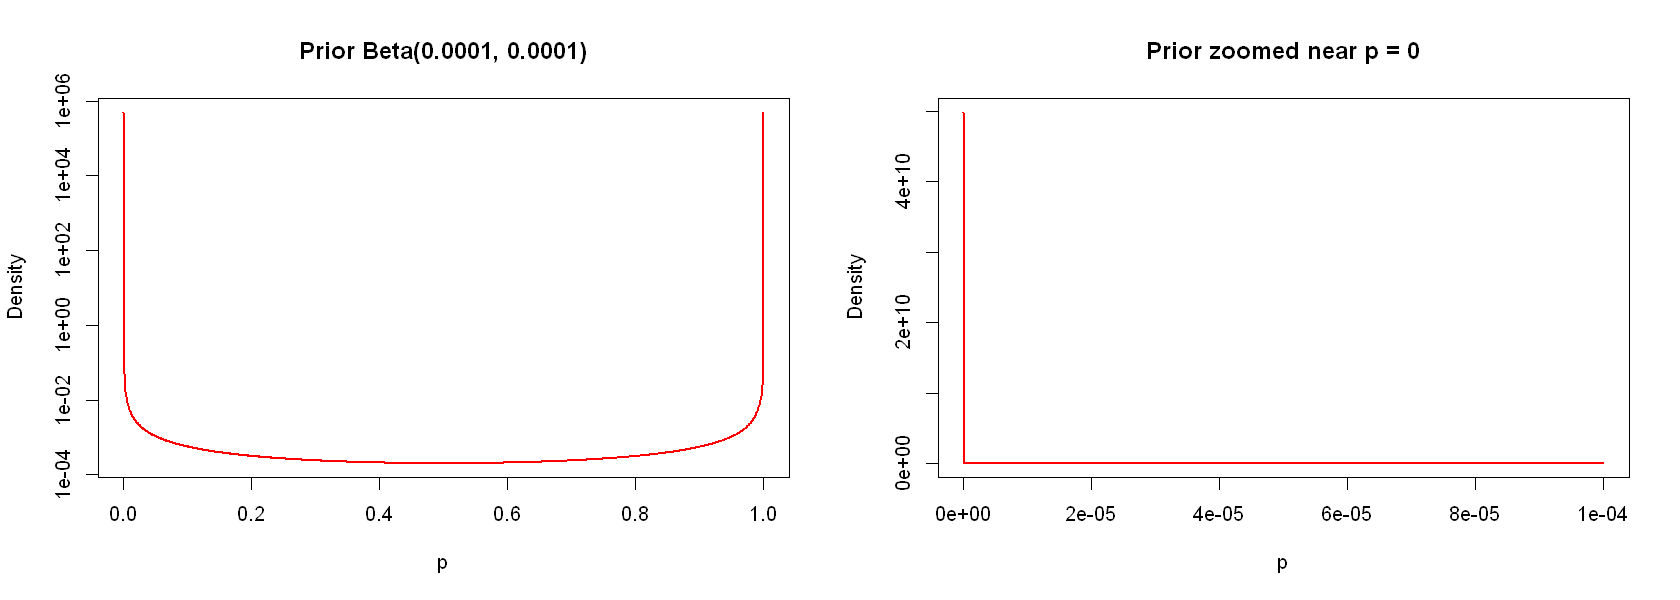

In [9]:
par(bg = "white", mfrow = c(1, 2))
options(repr.plot.width = 14, repr.plot.height = 5)

alpha <- 0.0001

# Left plot: log prior density across (0,1)
x <- seq(1e-10, 1 - 1e-10, length.out = 1000)
plot(x, dbeta(x, alpha, alpha), type = "l", col = "red", lwd = 2,
     xlab = "p", ylab = "Density", main = "Prior Beta(0.0001, 0.0001)",
     log = "y")

# Right plot: zoom into p near 0
x_zoom <- seq(1e-15, 1e-4, length.out = 1000)
plot(x_zoom, dbeta(x_zoom, alpha, alpha), type = "l", col = "red", lwd = 2,
     xlab = "p", ylab = "Density", main = "Prior zoomed near p = 0")

With $\alpha = 0.0001$, this is $\text{Beta}(0.0001, 0.0001)$, an extremely U-shaped distribution with nearly all mass concentrated at $p = 0$ and $p = 1$. This prior essentially says that the variance proportion is either approximately 0 (no random effects) or approximately 1 (all variance from random effects), with almost no prior weight on intermediate values.

This is arguably not a reasonable representation of prior beliefs in a typical applied setting. In most applications, one would expect the proportion of variance from random effects to lie somewhere between 0 and 1, not be forced to the extremes. A more reasonable prior might place more mass on intermediate values of $p$.

### Part f) Improper prior with $\alpha \to 0$

In the limiting case $\alpha \to 0$, the priors become improper scale priors $\pi(\tau) \propto 1/\tau$ and $\pi(\nu) \propto 1/\nu$. The full conditionals from part b) remain proper with $\alpha = 0$, so the Gibbs sampler can still run. However, the posterior itself may become improper meaning the chain will not converge. We investigate this by running the sampler with different initial values and examining trace plots.

In [10]:
#Gibbs sampler with alpha = 0 (improper prior) using different initial values
set.seed(123)
result_f1 <- gibbs_sampler(data, n_iter = 20000, alpha = 0)

set.seed(456)
result_f2 <- gibbs_sampler(data, n_iter = 20000, alpha = 0)

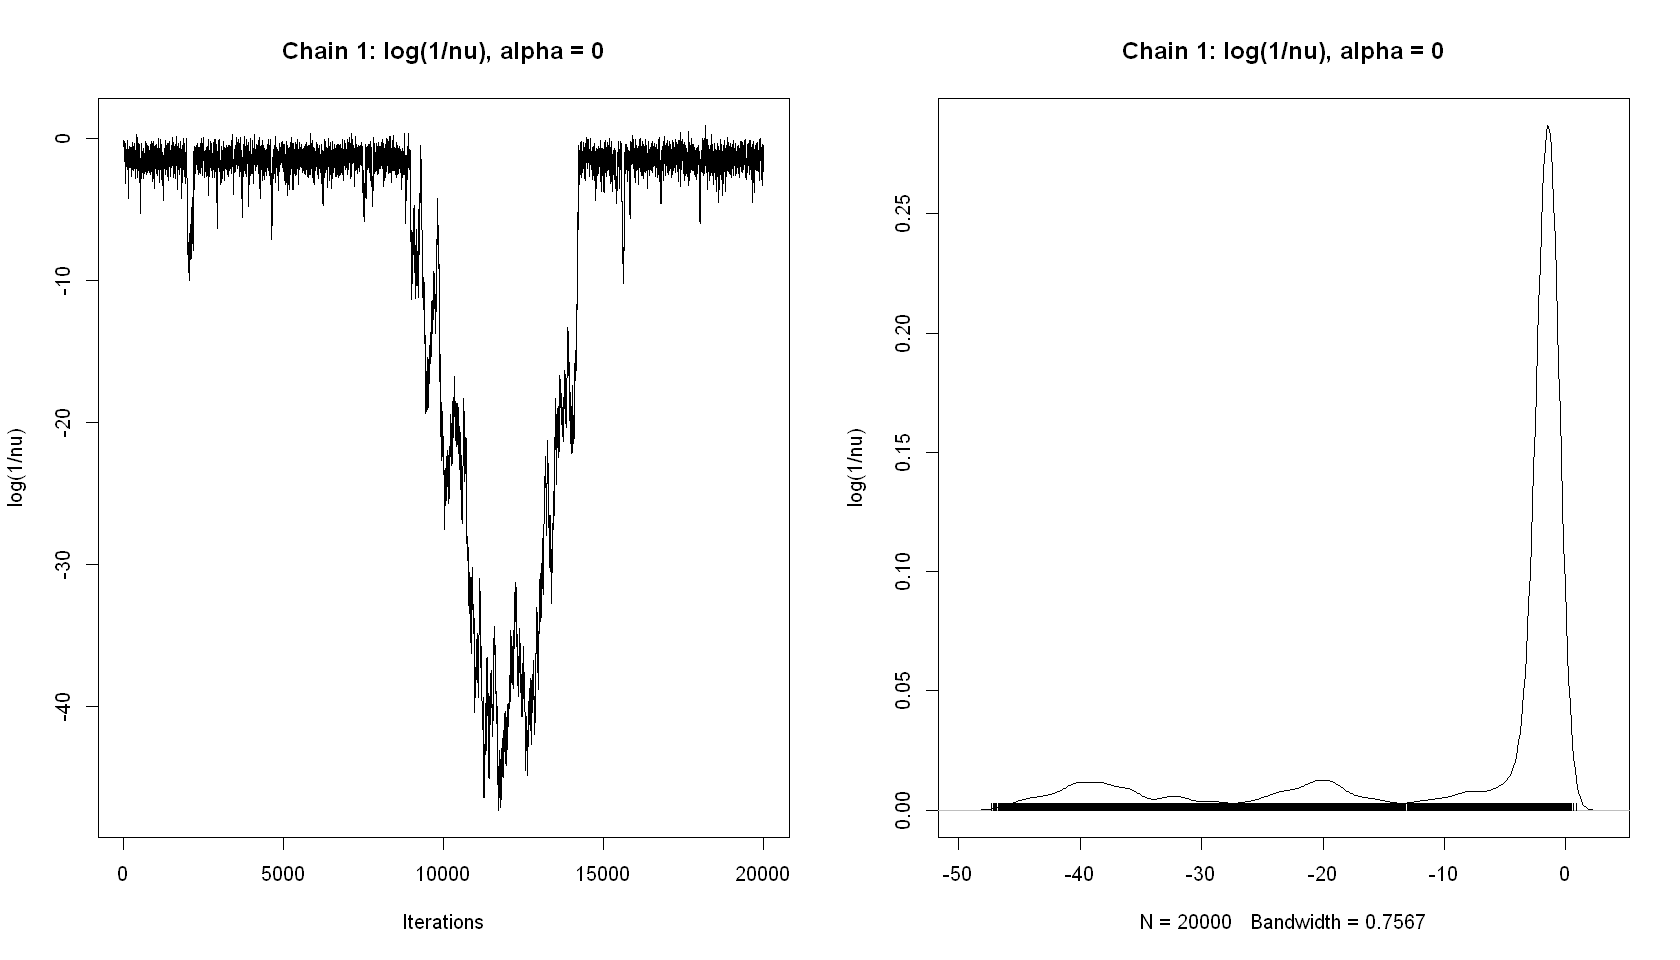

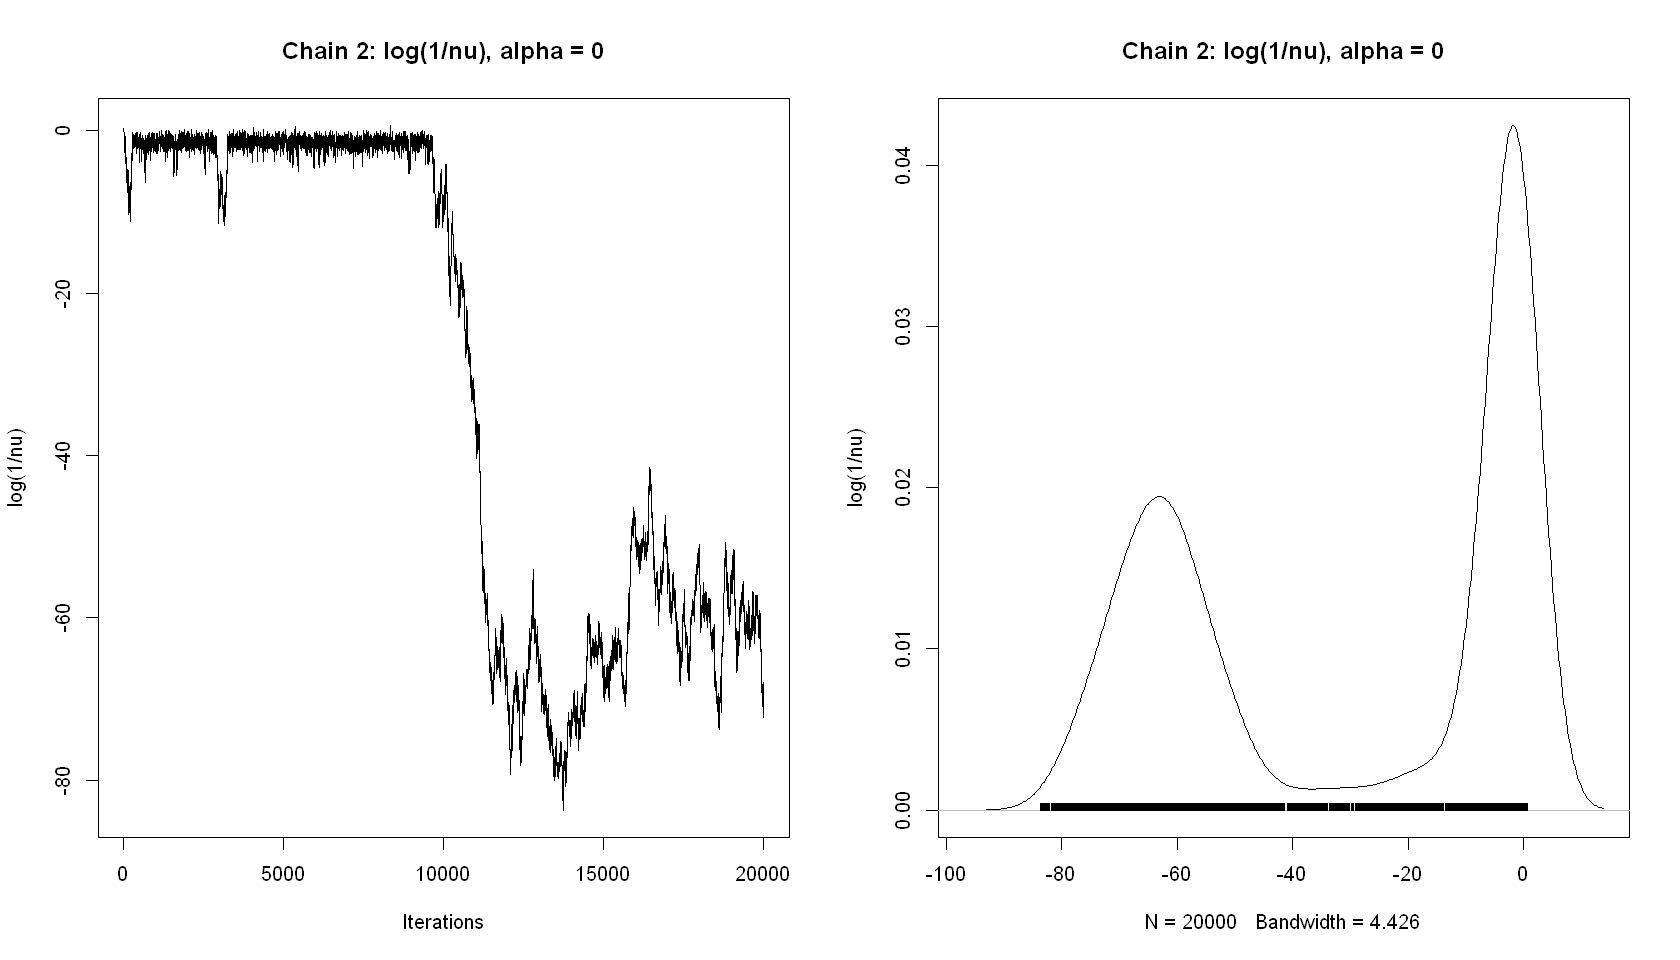

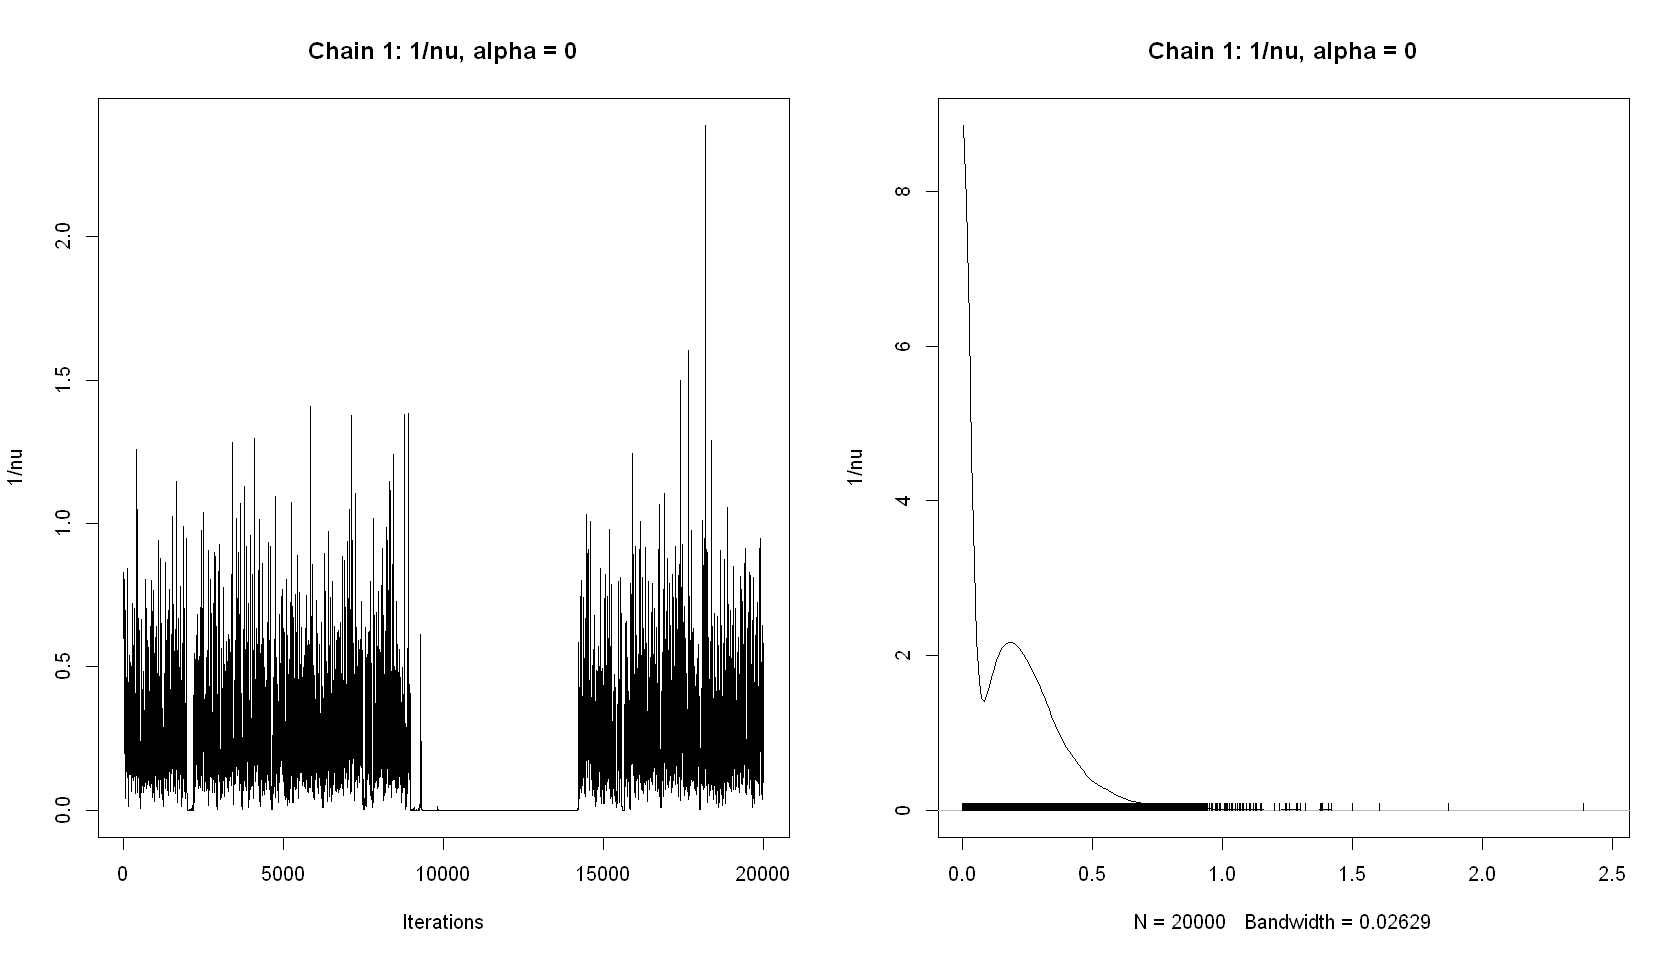

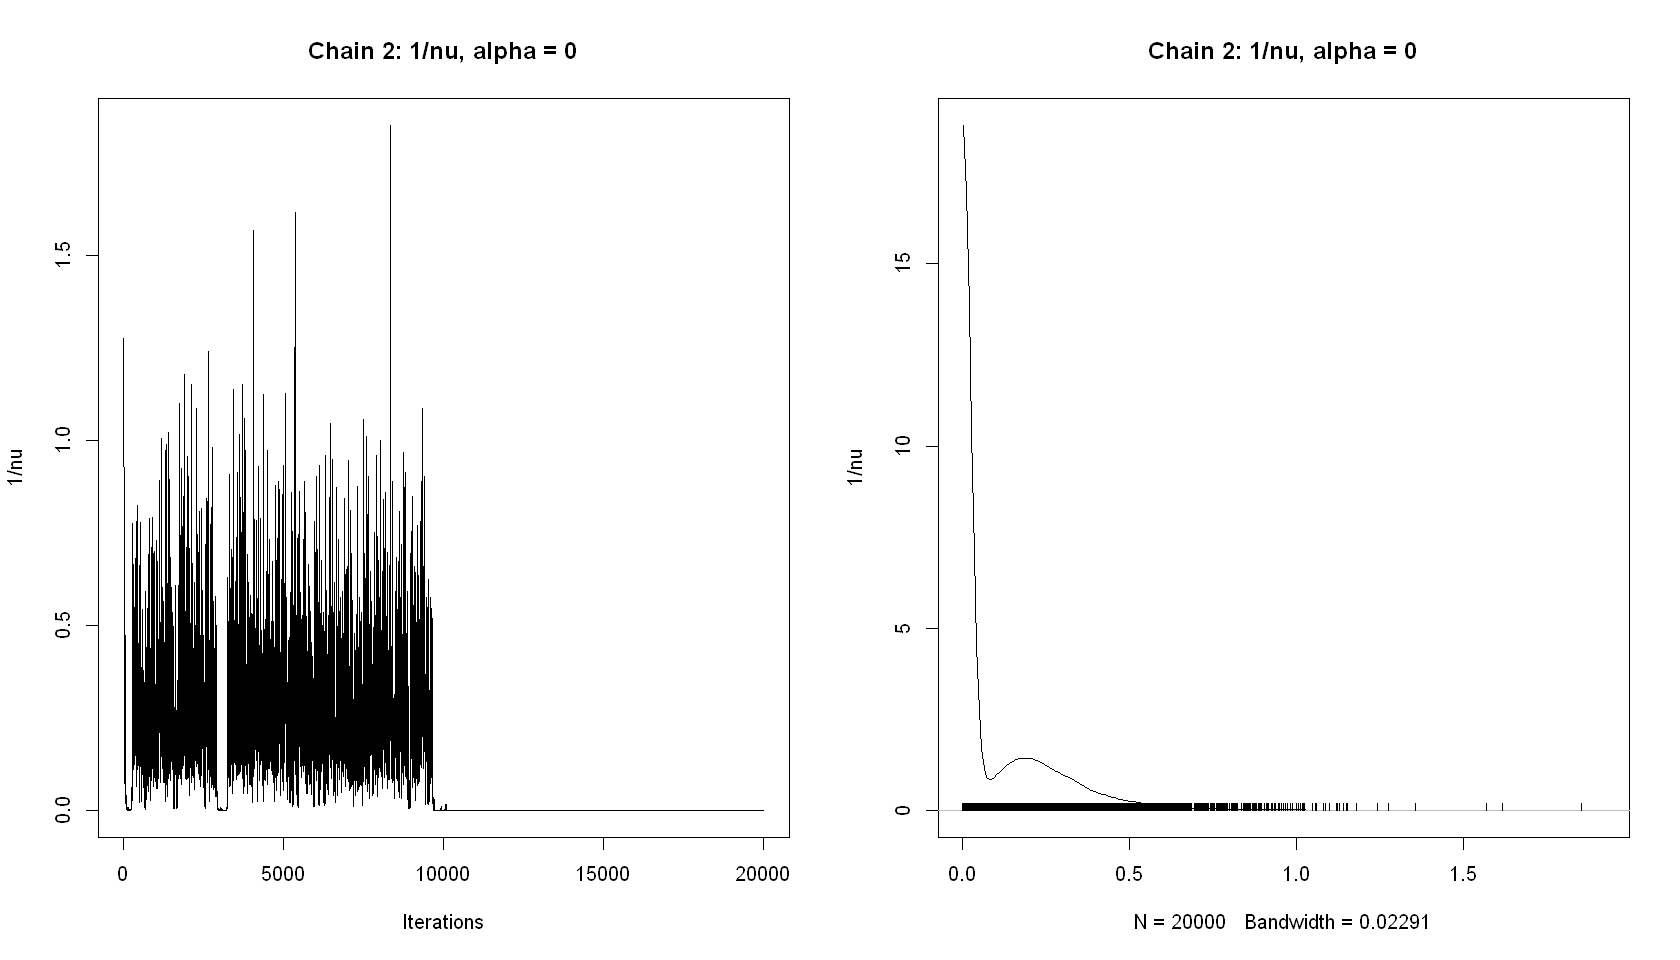

In [11]:
par(bg = "white", mfrow = c(2, 2))
options(repr.plot.width = 14, repr.plot.height = 8)

# Trace plots of log(1/nu) for the two chains
plot(log(result_f1[, "1/nu"]), main = "Chain 1: log(1/nu), alpha = 0", ylab = "log(1/nu)")
plot(log(result_f2[, "1/nu"]), main = "Chain 2: log(1/nu), alpha = 0", ylab = "log(1/nu)")

# Trace plots of 1/nu for the two chains
plot(result_f1[, "1/nu"], main = "Chain 1: 1/nu, alpha = 0", ylab = "1/nu")
plot(result_f2[, "1/nu"], main = "Chain 2: 1/nu, alpha = 0", ylab = "1/nu")

In [12]:
# Compare summaries
cat("=== Chain 1 (alpha = 0) ===\n")
summary(result_f1[, c("mu", "1/tau", "1/nu")])
cat("\n=== Chain 2 (alpha = 0) ===\n")
summary(result_f2[, c("mu", "1/tau", "1/nu")])

=== Chain 1 (alpha = 0) ===



Iterations = 1:20000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 20000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean     SD  Naive SE Time-series SE
mu    10.1871 0.1323 0.0009357       0.001961
1/tau  0.8569 0.1686 0.0011918       0.014387
1/nu   0.1842 0.1798 0.0012711       0.013998

2. Quantiles for each variable:

           2.5%       25%     50%     75%   97.5%
mu    9.922e+00 1.010e+01 10.1876 10.2708 10.4488
1/tau 5.895e-01 7.319e-01  0.8345  0.9647  1.2323
1/nu  9.165e-19 2.779e-04  0.1627  0.2850  0.6006



=== Chain 2 (alpha = 0) ===



Iterations = 1:20000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 20000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean     SD  Naive SE Time-series SE
mu    10.1863 0.1227 0.0008676       0.001703
1/tau  0.9152 0.1792 0.0012673       0.019172
1/nu   0.1167 0.1677 0.0011858       0.020490

2. Quantiles for each variable:

           2.5%       25%       50%     75%   97.5%
mu    9.938e+00 1.011e+01 1.019e+01 10.2649 10.4233
1/tau 6.064e-01 7.813e-01 9.079e-01  1.0358  1.2906
1/nu  7.964e-34 1.146e-27 3.701e-05  0.2099  0.5386


Comments on $\alpha = 0$

There are clear signs that the posterior for $\nu$ becomes improper when using the scale prior $\pi(\nu) \propto 1/\nu$:

1. The two chains give different answers: Chain 1 estimates $E[1/\nu] \approx 0.184$ while Chain 2 gives $\approx 0.117$. If the posterior were proper, both chains would converge to the same distribution regardless of the random seed.

2. Extreme values of $1/\nu$: The 2.5\% quantiles are astronomically small ($\approx 10^{-19}$ and $\approx 10^{-34}$), meaning the chain frequently visits values where $\nu$ is enormous and $1/\nu \approx 0$. This indicates the chain drifts toward $\nu \to \infty$.

3. Poor mixing: The time-series standard errors for $1/\nu$ are very large relative to the mean (about 8–18\% of the mean), compared to $\sim$1.5\% for the $\alpha = 0.0001$ case. The chain is not exploring a stable distribution.

4. Contamination of other parameters: The estimates for $1/\tau$ also differ between chains (0.857 vs 0.915), because $\tau$ and $\nu$ are coupled through the $\gamma_i$'s. When $\nu \to \infty$, the $\gamma_i$'s are shrunk to zero and their variance gets absorbed into the residual variance $1/\tau$.

5. Trace plots of $\log(1/\nu)$ show the chain drifting to very negative values (corresponding to $1/\nu \to 0$) without stabilizing, confirming non-convergence.

The improper scale prior $\pi(\nu) \propto 1/\nu$ places too much mass near $\nu = 0$ (i.e., infinite random intercept variance) and near $\nu = \infty$ (i.e., no random effects). With only $m = 20$ groups, the data cannot overcome this, and the posterior remains improper.

### Part g) Alternative prior via change of variables

We use a change of variables from $(\sigma^2, p)$ to $(\tau, \nu)$, where:

$$\sigma^2 = \nu^{-1} + \tau^{-1}, \qquad p = \frac{\nu^{-1}}{\nu^{-1} + \tau^{-1}} = \frac{\tau}{\tau + \nu}$$

The Jacobian matrix of the transformation is:

$$J = \begin{pmatrix} \frac{\partial \sigma^2}{\partial \tau} & \frac{\partial \sigma^2}{\partial \nu} \\ \frac{\partial p}{\partial \tau} & \frac{\partial p}{\partial \nu} \end{pmatrix} = \begin{pmatrix} -\tau^{-2} & -\nu^{-2} \\ \frac{\nu}{(\tau+\nu)^2} & \frac{-\tau}{(\tau+\nu)^2} \end{pmatrix}$$

The determinant is:

$$|J| = \left|(-\tau^{-2})\cdot\frac{-\tau}{(\tau+\nu)^2} - (-\nu^{-2})\cdot\frac{\nu}{(\tau+\nu)^2}\right| = \left|\frac{\tau^{-1}}{(\tau+\nu)^2} + \frac{\nu^{-1}}{(\tau+\nu)^2}\right|$$

$$= \frac{\tau^{-1} + \nu^{-1}}{(\tau+\nu)^2} = \frac{\frac{\tau+\nu}{\tau\nu}}{(\tau+\nu)^2} = \frac{1}{\tau\nu(\tau+\nu)}$$

Applying the change of variables formula with $\pi(\sigma^2, p) \propto \frac{1}{\sigma^2}$:

$$\pi(\tau, \nu) = \frac{1}{\sigma^2} \cdot |J| = \frac{1}{\nu^{-1}+\tau^{-1}} \cdot \frac{1}{\tau\nu(\tau+\nu)} = \frac{\tau\nu}{\tau+\nu} \cdot \frac{1}{\tau\nu(\tau+\nu)} = \frac{1}{(\tau+\nu)^2}$$

$$\boxed{\pi(\tau, \nu) \propto \frac{1}{(\tau+\nu)^2} I(\tau>0)I(\nu>0)}$$

which is exactly (7b). $\square$

---


We want to find the conditional prior of $\ln\tau$ given $\ln\nu$ under the prior $\pi(\tau, \nu) \propto \frac{1}{(\tau+\nu)^2}$.

Let $s = \ln\tau$ and $r = \ln\nu$, so $\tau = e^s$ and $\nu = e^r$. The Jacobian of this transformation is $\tau\nu = e^{s+r}$ (since $d\tau = e^s\,ds$ and $d\nu = e^r\,dr$). Therefore:

$$\pi(s, r) = \frac{1}{(e^s + e^r)^2} \cdot e^s \cdot e^r = \frac{e^{s+r}}{(e^s + e^r)^2}$$

To find the conditional $\pi(s | r)$, treat $r$ as fixed. Factor out $e^{2r}$ from the denominator:

$$\pi(s | r) \propto \frac{e^{s+r}}{(e^s + e^r)^2} = \frac{e^s \cdot e^r}{e^{2r}(e^{s-r} + 1)^2} \propto \frac{e^{s-r}}{(1 + e^{s-r})^2}$$

Let $w = s - r = \ln\tau - \ln\nu$. Then:

$$\pi(w) = \frac{e^w}{(1 + e^w)^2}$$

This is exactly the density of a **standard logistic distribution** (location 0, scale 1). Since $w = s - r = \ln\tau - \ln\nu$, we have:

$$\boxed{\ln\tau \mid \ln\nu \sim \text{Logistic}(\ln\nu, 1)}$$

$\square$

---

#### Comment on the prior

The prior (7) is arguably more reasonable than (4) in an applied setting. It places a uniform prior on the proportion of variance $p \in (0,1)$ attributed to the random intercept, meaning all values of $p$ are equally plausible a priori. This is in contrast to the $\text{Beta}(0.0001, 0.0001)$ prior implied by (4), which concentrates all mass at $p = 0$ and $p = 1$. In most applications, one would not want to rule out intermediate values of $p$ a priori, making (7) a more sensible default choice.

### Part h) Modified Gibbs sampler with prior (7)

The full conditionals for $\mu$ and $\gamma_i$ are unchanged since prior (7) does not involve them. For $\tau$ and $\nu$, we cannot sample directly from the full conditionals under the new prior $\pi(\tau, \nu) \propto \frac{1}{(\tau+\nu)^2}$. Instead, we use a Metropolis-Hastings step where the proposal $Q$ is the full conditional from (4) with $\alpha = 0$ (the scale prior).

Under the old prior ($\alpha = 0$), the full conditional for $\tau$ is:
$$Q(\tau' | \ldots) \propto \tau'^{n/2 - 1} \exp\left(-\frac{\tau'}{2}\sum_{i}\sum_{j}(y_{ij}-\mu-\gamma_i)^2\right)$$

Under the new prior (7b), the full conditional for $\tau$ is:
$$\pi(\tau' | \ldots) \propto \tau'^{n/2} \exp\left(-\frac{\tau'}{2}\sum_{i}\sum_{j}(y_{ij}-\mu-\gamma_i)^2\right) \cdot \frac{1}{(\tau'+\nu)^2}$$

The extra factor compared to the proposal is $\frac{\tau'}{(\tau'+\nu)^2}$ (the ratio of new prior to old prior). The acceptance probability is therefore:

$$\alpha(\tau' | \tau) = \min\left(1, \; \frac{\tau'(\tau+\nu)^2}{\tau(\tau'+\nu)^2}\right)$$

Similarly for $\nu$:

$$\alpha(\nu' | \nu) = \min\left(1, \; \frac{\nu'(\nu+\tau)^2}{\nu(\nu'+\tau)^2}\right)$$

In [13]:
gibbs_sampler_h <- function(data, n_iter = 20000) {
  # Extract data
  y <- data$y
  groups <- data$i
  m <- length(unique(groups))
  n <- length(y)
  
  group_idx <- split(seq_along(y), groups)
  n_i <- sapply(group_idx, length)
  
  # Initialize parameters
  mu <- mean(y)
  gamma <- rep(0, m)
  tau <- 1
  nu <- 1
  
  # Storage matrix: mu, 1/tau, 1/nu, gamma_1, ..., gamma_m
  p <- 3 + m
  samples <- matrix(0, nrow = n_iter, ncol = p)
  col_names <- c("mu", "1/tau", "1/nu", paste0("gamma_", 1:m))
  colnames(samples) <- col_names
  
  # Track acceptance rates
  tau_accept <- 0
  nu_accept <- 0
  
  for (t in 1:n_iter) {
    # --- Sample mu (unchanged) ---
    sum_y_minus_gamma <- sum(y - gamma[groups])
    mu_mean <- sum_y_minus_gamma / n
    mu_var <- 1 / (n * tau)
    mu <- rnorm(1, mean = mu_mean, sd = sqrt(mu_var))
    
    # --- Sample each gamma_i (unchanged) ---
    for (k in 1:m) {
      idx <- group_idx[[k]]
      sum_y_minus_mu <- sum(y[idx] - mu)
      gamma_prec <- n_i[k] * tau + nu
      gamma_mean <- (tau * sum_y_minus_mu) / gamma_prec
      gamma_var <- 1 / gamma_prec
      gamma[k] <- rnorm(1, mean = gamma_mean, sd = sqrt(gamma_var))
    }
    
    # --- Sample tau (MH step) ---
    # Proposal from full conditional under alpha=0 scale prior
    resid <- y - mu - gamma[groups]
    tau_shape <- n / 2
    tau_rate <- sum(resid^2) / 2
    tau_prop <- rgamma(1, shape = tau_shape, rate = tau_rate)
    
    # Acceptance probability
    log_alpha_tau <- log(tau_prop) - 2 * log(tau_prop + nu) -
                     log(tau)      + 2 * log(tau + nu)
    if (log(runif(1)) < log_alpha_tau) {
      tau <- tau_prop
      tau_accept <- tau_accept + 1
    }
    
    # --- Sample nu (MH step) ---
    # Proposal from full conditional under alpha=0 scale prior
    nu_shape <- m / 2
    nu_rate <- sum(gamma^2) / 2
    nu_prop <- rgamma(1, shape = nu_shape, rate = nu_rate)
    
    # Acceptance probability
    log_alpha_nu <- log(nu_prop) - 2 * log(nu_prop + tau) -
                    log(nu)      + 2 * log(nu + tau)
    if (log(runif(1)) < log_alpha_nu) {
      nu <- nu_prop
      nu_accept <- nu_accept + 1
    }
    
    # Store samples
    samples[t, ] <- c(mu, 1/tau, 1/nu, gamma)
  }
  
  cat("Tau acceptance rate:", tau_accept / n_iter, "\n")
  cat("Nu acceptance rate:", nu_accept / n_iter, "\n")
  
  return(mcmc(samples))
}

# Run the modified Gibbs sampler
set.seed(42)
result_h <- gibbs_sampler_h(data, n_iter = 20000)

Tau acceptance rate: 0.9639 
Nu acceptance rate: 0.9173 


In [14]:
# Summary and comparison with part d)
summary(result_h[, c("mu", "1/tau", "1/nu")])


Iterations = 1:20000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 20000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

         Mean     SD  Naive SE Time-series SE
mu    10.1903 0.1523 0.0010769       0.002498
1/tau  0.7712 0.1235 0.0008733       0.001242
1/nu   0.3016 0.1637 0.0011576       0.002564

2. Quantiles for each variable:

         2.5%     25%     50%     75%   97.5%
mu    9.89347 10.0888 10.1904 10.2881 10.4950
1/tau 0.56834  0.6830  0.7585  0.8469  1.0436
1/nu  0.07726  0.1888  0.2694  0.3803  0.7192


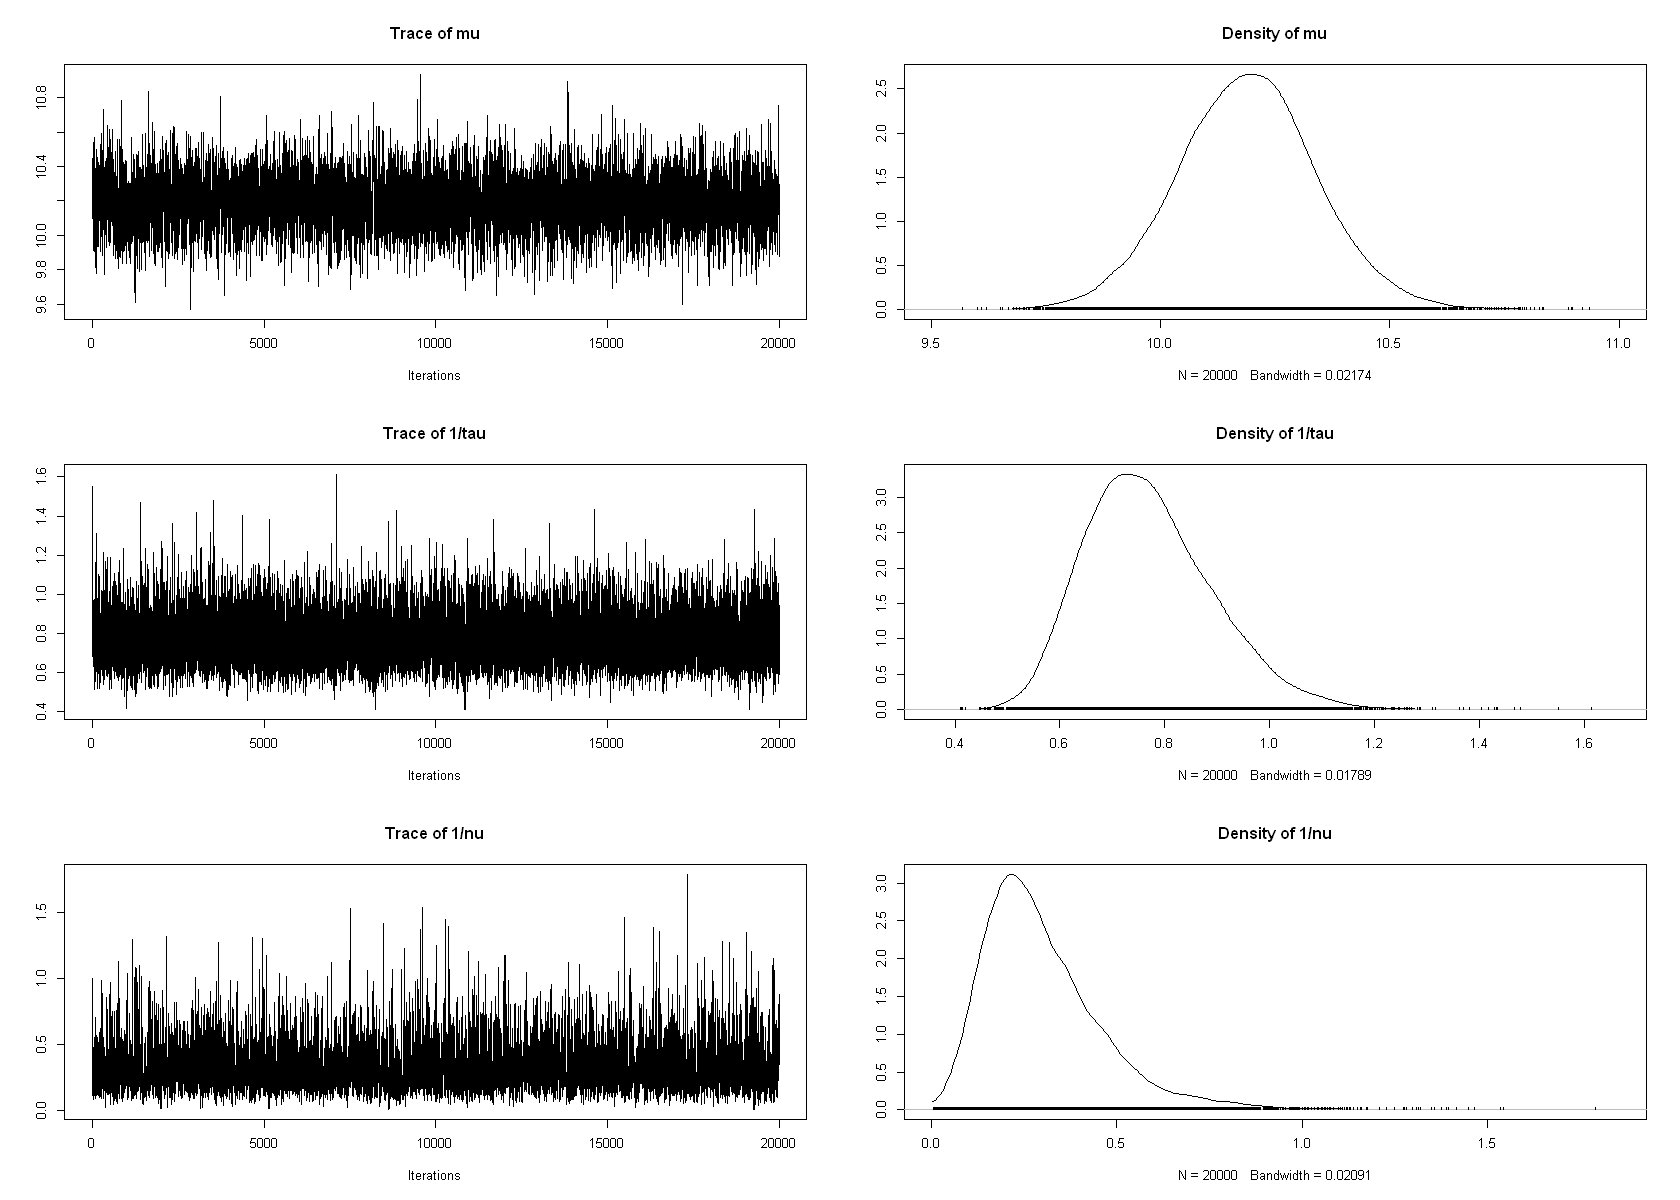

In [15]:
# Trace plots
par(bg = "white")
options(repr.plot.width = 14, repr.plot.height = 10)
plot(result_h[, c("mu", "1/tau", "1/nu")])

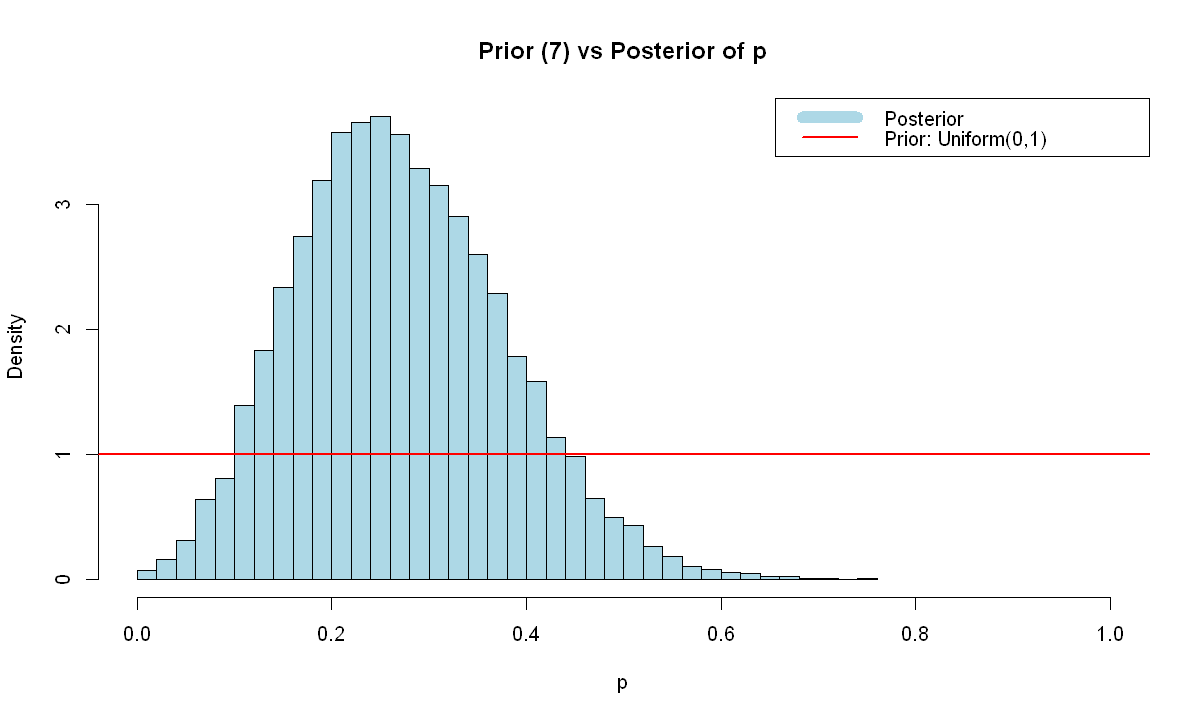

In [16]:
# Compare posterior of p with prior (7): Uniform(0,1)
par(bg = "white")
options(repr.plot.width = 10, repr.plot.height = 6)

inv_tau_h <- result_h[, "1/tau"]
inv_nu_h <- result_h[, "1/nu"]
p_post_h <- inv_nu_h / (inv_nu_h + inv_tau_h)

hist(p_post_h, breaks = 50, probability = TRUE, col = "lightblue",
     main = "Prior (7) vs Posterior of p", xlab = "p", xlim = c(0, 1))
abline(h = 1, col = "red", lwd = 2)  # Uniform(0,1) prior
legend("topright", legend = c("Posterior", "Prior: Uniform(0,1)"),
       col = c("lightblue", "red"), lwd = c(10, 2))

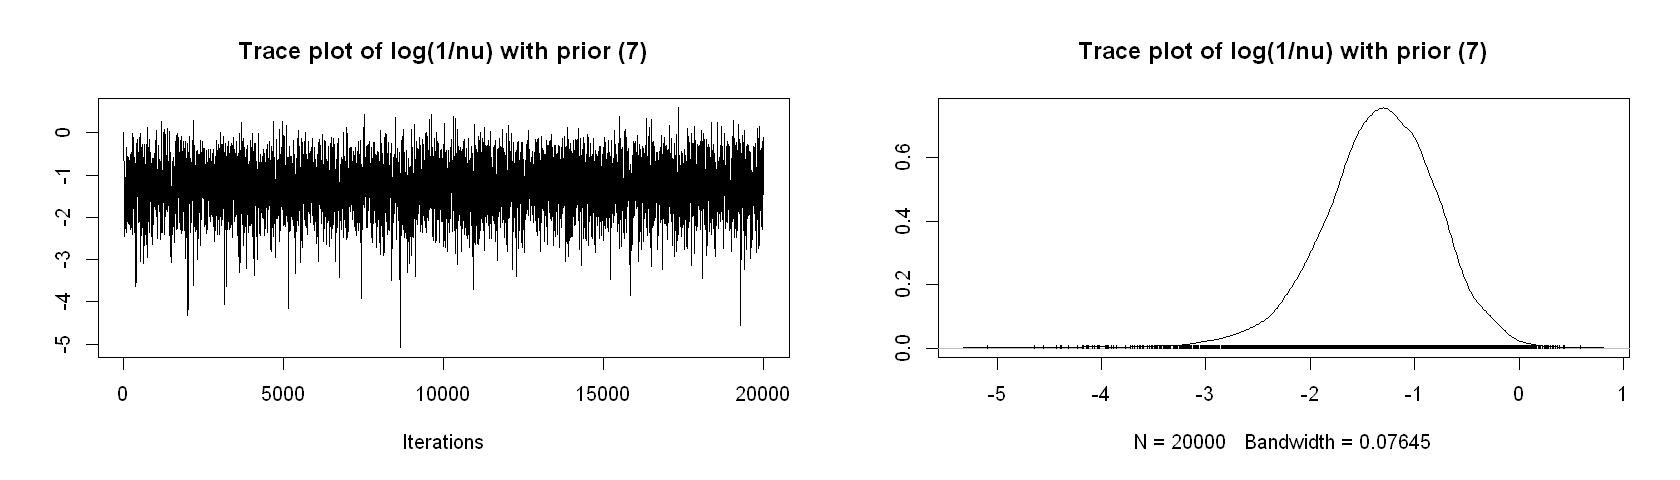

In [19]:
# Trace plot of log(1/nu) to compare with part f)
par(bg = "white")
options(repr.plot.width = 14, repr.plot.height = 4)
plot(log(result_h[, "1/nu"]), main = "Trace plot of log(1/nu) with prior (7)")


Comments on part h)

Acceptance rates: The MH acceptance rates are very high (96% for $\tau$, 92% for $\nu$), confirming that the full conditionals under (4) are excellent proposals for the target under (7).

Comparison with part d) (prior (4), $\alpha = 0.0001$):

| Parameter | MLE | Part d) posterior mean | Part h) posterior mean |
|-----------|-----|----------------------|----------------------|
| $\mu$ | 10.1888 | 10.1907 | 10.1903 |
| $1/\tau$ | 0.7560 | 0.8012 | 0.7712 |
| $1/\nu$ | 0.2301 | 0.2464 | 0.3016 |

The estimates are similar, though $1/\nu$ is slightly larger under prior (7). This is because the uniform prior on $p$ places more weight on intermediate values of $1/\nu$ compared to the $\text{Beta}(0.0001, 0.0001)$ prior.

Convergence: Unlike part f), the convergence issues have disappeared. The trace plots show good mixing for all parameters, including $1/\nu$. The 2.5\% quantile of $1/\nu$ is 0.077, compared to the extreme values of $10^{-19}$ and $10^{-34}$ seen in part f). This demonstrates that the convergence problem in part f) was caused by the scale prior $\pi(\nu) \propto 1/\nu$, not by the use of an improper prior per se. The prior (7), while also improper, leads to a proper posterior because it does not place excessive mass near $\nu = 0$ or $\nu = \infty$.

Posterior of $p$: The posterior of the variance proportion $p$ is concentrated around 0.2–0.3, consistent with the MLE. The prior is now Uniform(0,1), which is much more reasonable than the $\text{Beta}(0.0001, 0.0001)$ from part e).

---

## Problem 3

#### Problem definitions

We want to model the (log of) hourly cloud ceiling heights as a first order auto-regressive model of the form
$$
y_t - \mu = \phi (y_{t-1} - \mu) + \varepsilon_t.
$$

As joint prior we use the improper density
$$
\pi (\mu , \phi , \tau) \propto I(-1 < \phi < 1) I(\tau > 0) \frac{1}{\tau}.
$$

The process is assumed to be stationary. 

---

### Part a) Expectation and Variance
Let
$$
m = \mathbb E(y_t \mid \mu,\phi,\tau).
$$

Taking expectation on both sides of the model gives
$$
\mathbb E(y_t \mid \mu,\phi,\tau)
=
\mu + \phi\bigl(\mathbb E(y_{t-1}\mid \mu,\phi,\tau)-\mu\bigr) + \mathbb E(\varepsilon_t) = \mu + \phi \bigl( m - \mu \bigr)
$$
since $\mathbb E(\varepsilon_t)=0$ and process is stationary.

Thus, 
$$
m = \mu + \phi(m-\mu) \quad \Longrightarrow \quad (1-\phi)m=(1-\phi)\mu \quad \Longrightarrow \quad m = \mu.
$$

Hence,
$$
\mathbb E(y_1\mid \mu,\phi,\tau)=\mu.
$$

Next, let
$$
v=\operatorname{Var}(y_t\mid \mu,\phi,\tau).
$$
From the model,
$$
y_t-\mu=\phi(y_{t-1}-\mu)+\varepsilon_t.
$$
Taking variance on both sides gives
$$
\operatorname{Var}(y_t-\mu\mid \mu,\phi,\tau)
=
\operatorname{Var}\bigl(\phi(y_{t-1}-\mu)+\varepsilon_t \mid \mu,\phi,\tau\bigr).
$$
Because $\varepsilon_t$ is independent of $y_{t-1}$, and
$$
\operatorname{Var}(\varepsilon_t)=\tau^{-1},
$$
it follows that
$$
v=\phi^2 v+\tau^{-1}.
$$
Thus,
$$
v(1-\phi^2)=\tau^{-1},
$$
and since $|\phi|<1$,
$$
v=\frac{\tau^{-1}}{1-\phi^2}.
$$
Therefore,
$$
\operatorname{Var}(y_1\mid \mu,\phi,\tau)=\frac{\tau^{-1}}{1-\phi^2}.
$$

So under stationarity,
$$
\boxed{
\mathbb E(y_1\mid \mu,\phi,\tau)=\mu,
\qquad
\operatorname{Var}(y_1\mid \mu,\phi,\tau)=\frac{\tau^{-1}}{1-\phi^2}.
}
$$
---

### Part b) Reparameterization and joint posterior

#### Joint prior on $\beta_0, \beta_1, \tau$:

Starting from the model
$$
y_t-\mu=\phi(y_{t-1}-\mu)+\varepsilon_t,
$$
we expand the right-hand side:
$$
y_t=\mu+\phi y_{t-1}-\phi\mu+\varepsilon_t
=\mu(1-\phi)+\phi y_{t-1}+\varepsilon_t.
$$
Comparing this with the reparameterized form
$$
y_t=\beta_0+\beta_1 y_{t-1}+\varepsilon_t,
$$
we identify
$$
\beta_0=\mu(1-\phi), \qquad \beta_1=\phi.
$$
Equivalently,
$$
\phi=\beta_1, \qquad \mu=\frac{\beta_0}{1-\beta_1}.
$$

The original prior is
$$
\pi(\mu,\phi,\tau)\propto I(-1<\phi<1)\,I(\tau>0)\,\frac{1}{\tau}.
$$

To find the prior in terms of $(\beta_0,\beta_1,\tau)$, we use the change-of-variables formula:
$$
\pi(\beta_0,\beta_1,\tau)
=
\pi(\mu,\phi,\tau)
\left|
\frac{\partial(\mu,\phi,\tau)}{\partial(\beta_0,\beta_1,\tau)}
\right|.
$$

Since $\tau$ is unchanged, it is enough to compute the Jacobian for $(\mu,\phi)$ as functions of $(\beta_0,\beta_1)$:
$$
\mu=\frac{\beta_0}{1-\beta_1}, \qquad \phi=\beta_1.
$$
Hence,
$$
\frac{\partial(\mu,\phi)}{\partial(\beta_0,\beta_1)}
=
\begin{pmatrix}
\frac{\partial \mu}{\partial \beta_0} & \frac{\partial \mu}{\partial \beta_1} \\[1ex]
\frac{\partial \phi}{\partial \beta_0} & \frac{\partial \phi}{\partial \beta_1}
\end{pmatrix}
=
\begin{pmatrix}
\frac{1}{1-\beta_1} & \frac{\beta_0}{(1-\beta_1)^2} \\[1ex]
0 & 1
\end{pmatrix}.
$$
Its determinant is
$$
\left|
\frac{\partial(\mu,\phi)}{\partial(\beta_0,\beta_1)}
\right|
=
\frac{1}{1-\beta_1}.
$$

Therefore,
$$
\pi(\beta_0,\beta_1,\tau)
\propto
I(-1<\beta_1<1)\,I(\tau>0)\,\frac{1}{\tau}\cdot \frac{1}{1-\beta_1}.
$$
That is,
$$
\pi(\beta_0,\beta_1,\tau)
\propto
I(-1<\beta_1<1)\,I(\tau>0)\,\frac{1}{1-\beta_1}\,\frac{1}{\tau}.
$$

Thus, up to a constant of proportionality, the joint prior becomes
$$
\boxed{
\pi(\beta_0,\beta_1,\tau)
=
I(-1<\beta_1<1)\,I(\tau>0)\,\frac{1}{1-\beta_1}\,\frac{1}{\tau}
}
$$

---

#### Joint posterior:


Let
$$
\beta =
\begin{pmatrix}
\beta_0\\
\beta_1
\end{pmatrix},
\qquad
\mathbf y_{2:n}=
\begin{pmatrix}
y_2\\
\vdots\\
y_n
\end{pmatrix},
\qquad
\mathbf X=
\begin{pmatrix}
1 & y_1\\
1 & y_2\\
\vdots & \vdots\\
1 & y_{n-1}
\end{pmatrix}.
$$

We write the model as
$$
y_t \mid y_{t-1},\beta,\tau \sim \mathcal N(\beta_0+\beta_1 y_{t-1},\tau^{-1}),
\qquad t=2,\dots,n.
$$

Also, under stationarity,
$$
y_1\mid \beta,\tau \sim \mathcal N\left(\frac{\beta_0}{1-\beta_1},\frac{\tau^{-1}}{1-\beta_1^2}\right).
$$

From part b), the prior is
$$
\pi(\beta_0,\beta_1,\tau)
\propto
I(-1<\beta_1<1)\,I(\tau>0)\,\frac{1}{1-\beta_1}\,\frac{1}{\tau},
$$

which we use to to find the conditional density of $y_{2:n}$ given $y_1,\beta,\tau$ as
$$
\pi(\mathbf y_{2:n}\mid y_1,\beta,\tau)
=
\prod_{t=2}^n
\left(\frac{\tau}{2\pi}\right)^{1/2}
\exp\left(
-\frac{\tau}{2}(y_t-\beta_0-\beta_1 y_{t-1})^2
\right).
$$
This gives
$$
\pi(\mathbf y_{2:n}\mid y_1,\beta,\tau)
\propto
\tau^{(n-1)/2}
\exp\left(
-\frac{\tau}{2}\sum_{t=2}^n (y_t-\beta_0-\beta_1 y_{t-1})^2
\right),
$$
which can be rewritten using matrix notation as
$$
\pi(\mathbf y_{2:n}\mid y_1,\beta,\tau)
\propto
\tau^{(n-1)/2}
\exp\left(
-\frac{\tau}{2}
(\mathbf y_{2:n}-\mathbf X\beta)^T(\mathbf y_{2:n}-\mathbf X\beta)
\right).
$$

Next, the density of the initial observation is
$$
\pi(y_1\mid \beta,\tau)
=
\left(\frac{\tau(1-\beta_1^2)}{2\pi}\right)^{1/2}
\exp\left(
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\right).
$$
So, up to proportionality,
$$
\pi(y_1\mid \beta,\tau)
\propto
\tau^{1/2}\sqrt{1-\beta_1^2}\,
\exp\left(
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\right).
$$

By Bayes' theorem,
$$
\pi(\beta,\tau\mid y)
\propto
\pi(\mathbf y_{2:n}\mid y_1,\beta,\tau)\,
\pi(y_1\mid \beta,\tau)\,
\pi(\beta_0,\beta_1,\tau).
$$
Substituting the expressions above gives
$$
\pi(\beta,\tau\mid y)
\propto
\tau^{(n-1)/2}
\exp\left(
-\frac{\tau}{2}
(\mathbf y_{2:n}-\mathbf X\beta)^T(\mathbf y_{2:n}-\mathbf X\beta)
\right)
$$
$$
\qquad\times\;
\tau^{1/2}\sqrt{1-\beta_1^2}\,
\exp\left(
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\right)
$$
$$
\qquad\times\;
I(-1<\beta_1<1)\,I(\tau>0)\,\frac{1}{1-\beta_1}\,\frac{1}{\tau}.
$$

Thus, the joint posterior density can be written as
$$
\boxed{
\pi(\beta,\tau\mid \mathbf y)
\propto
\tau^{n/2-1}
\exp\left(
-\frac{\tau}{2}
(\mathbf y_{2:n}-\mathbf X\beta)^T(\mathbf y_{2:n}-\mathbf X\beta)
\right)
\frac{\sqrt{1-\beta_1^2}\,I(-1<\beta_1<1)}{1-\beta_1}
\exp\left(
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\right)
}
$$

---

### Part c) Log acceptence probability

Let the target posterior density be written as
$$
\pi(\beta,\tau\mid \mathbf y)\propto q(\beta,\tau\mid \mathbf y)\,h(\beta,\tau),
$$
where $q(\beta,\tau\mid \mathbf y)$ is the part denoted by $(*)$, that is
$$
q(\beta,\tau\mid \mathbf y)
\propto
\tau^{n/2-1}
\exp\left(
-\frac{\tau}{2}
(\mathbf y_{2:n}-\mathbf X\beta)^T(\mathbf y_{2:n}-\mathbf X\beta)
\right),
$$
and
$$
h(\beta,\tau)
=
I(-1<\beta_1<1)\,
\frac{\sqrt{1-\beta_1^2}}{1-\beta_1}
\exp\left(
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\right).
$$

We want to use $q(\beta,\tau\mid \mathbf y)$ as a proposal density in a Metropolis-Hastings algorithm, then the proposal density 

$$
Q(\beta',\tau'\mid \beta,\tau, \mathbf y)=q(\beta',\tau'\mid \mathbf y),
$$
meaning it $Q(\beta',\tau'\mid \beta,\tau, \mathbf y)$ does not depend on the current state $(\beta,\tau)$.

The acceptance ratio becomes
$$
r(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\frac{
\pi(\beta',\tau'\mid \mathbf y)\,Q(\beta,\tau\mid \beta',\tau', \mathbf y)
}{
\pi(\beta,\tau\mid \mathbf y)\,Q(\beta',\tau'\mid \beta,\tau, \mathbf y)
}
=
\frac{
\pi(\beta',\tau'\mid \mathbf y)\,q(\beta,\tau\mid \mathbf y)
}{
\pi(\beta,\tau\mid \mathbf y)\,q(\beta',\tau'\mid \mathbf y)
}.
$$

Using $\pi(\beta,\tau\mid \mathbf y)\propto q(\beta,\tau\mid \mathbf y)\,h(\beta,\tau)$, the proposal terms cancel, giving
$$
r(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\frac{h(\beta',\tau')}{h(\beta,\tau)}.
$$
Therefore,
$$
\alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\min\left\{1,\frac{h(\beta',\tau')}{h(\beta,\tau)}\right\}.
$$

Taking logarithms gives
$$
\log \alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\min\left\{0,\log h(\beta',\tau')-\log h(\beta,\tau)\right\}.
$$

Now
$$
\log h(\beta,\tau)
=
\log I(-1<\beta_1<1)
+\frac12\log(1-\beta_1^2)
-\log(1-\beta_1)
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2.
$$
For $-1<\beta_1<1$,
$$
\frac12\log(1-\beta_1^2)-\log(1-\beta_1)
=
\frac12\log\left(\frac{1+\beta_1}{1-\beta_1}\right).
$$
Thus,
$$
\log h(\beta,\tau)
=
\log I(-1<\beta_1<1)
+\frac12\log\left(\frac{1+\beta_1}{1-\beta_1}\right)
-\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2.
$$

Hence the log acceptance probability is
$$
\log \alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\min\Bigg\{
0,\,
\log I(-1<\beta_1'<1)-\log I(-1<\beta_1<1)
$$
$$
\qquad
+\frac12\log\left(\frac{1+\beta_1'}{1-\beta_1'}\right)
-\frac12\log\left(\frac{1+\beta_1}{1-\beta_1}\right)
$$
$$
\qquad
-\frac{\tau'}{2}(1-\beta_1'^2)
\left(y_1-\frac{\beta_0'}{1-\beta_1'}\right)^2
+\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\Bigg\}.
$$

If both $\beta_1,\beta_1'\in(-1,1)$, the indicator terms are equal to $1$, so the expression simplifies to
$$
\boxed{
\log \alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)
=
\min\Bigg\{
0,\,
\frac12\log\left(\frac{1+\beta_1'}{1-\beta_1'}\right)
-\frac12\log\left(\frac{1+\beta_1}{1-\beta_1}\right)
\Bigg.
\Bigg.
-\frac{\tau'}{2}(1-\beta_1'^2)
\left(y_1-\frac{\beta_0'}{1-\beta_1'}\right)^2
+\frac{\tau}{2}(1-\beta_1^2)
\left(y_1-\frac{\beta_0}{1-\beta_1}\right)^2
\Bigg\}.
}
$$

If $\beta_1'\notin(-1,1)$, then the proposed value lies outside the support of the target density, and therefore
$$
\alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)=0,
\qquad
\log \alpha(\beta',\tau'\mid \beta,\tau, \mathbf y)=-\infty.
$$

---

### Part d) From $(*)$ to multivariate density and Gamma distribution

#### Multivariate density for $\beta \mid \tau$:

We again use
$$
(*) \propto \tau^{n/2-1}\exp\left(-\frac{\tau}{2}(\mathbf y_{2:n}-\mathbf X\beta)^T(\mathbf y_{2:n}-\mathbf X\beta)\right),
$$
for which we will factor into a multivariate normal density for $\beta\mid \tau$ and a Gamma density for $\tau$.

For simplicity, write
$$
\mathbf y=\mathbf y_{2:n}.
$$

We expand the exponent
$$
(\mathbf y-\mathbf X\beta)^T(\mathbf y-\mathbf X\beta)
=
\mathbf y^T\mathbf y-2\beta^T\mathbf X^T\mathbf y+\beta^T\mathbf X^T\mathbf X\beta,
$$
and define
$$
Q=\mathbf X^T\mathbf X,
\qquad
\hat\beta=(\mathbf X^T\mathbf X)^{-1}\mathbf X^T\mathbf y,
\qquad
\hat\varepsilon=\mathbf y-\mathbf X\hat\beta.
$$
We see that 
$$
\mathbf X^T\mathbf y=Q\hat\beta,
$$
which we can use to complete the square and get:
$$
\mathbf y^T\mathbf y-2\beta^TQ\hat\beta+\beta^TQ\beta
=
(\beta-\hat\beta)^TQ(\beta-\hat\beta)+\mathbf y^T\mathbf y-\hat\beta^TQ\hat\beta.
$$

Now observe that
$$
\hat\varepsilon^T\hat\varepsilon
=
(\mathbf y-\mathbf X\hat\beta)^T(\mathbf y-\mathbf X\hat\beta)
=
\mathbf y^T\mathbf y-\hat\beta^T\mathbf X^T\mathbf X\hat\beta
=
\mathbf y^T\mathbf y-\hat\beta^TQ\hat\beta,
$$
which we use to make
$$
(\mathbf y-\mathbf X\beta)^T(\mathbf y-\mathbf X\beta)
=
(\beta-\hat\beta)^TQ(\beta-\hat\beta)+\hat\varepsilon^T\hat\varepsilon.
$$

Substituting this into $(*)$ gives
$$
(*) \propto
\tau^{n/2-1}
\exp\left(-\frac{\tau}{2}(\beta-\hat\beta)^TQ(\beta-\hat\beta)\right)
\exp\left(-\frac{\tau}{2}\hat\varepsilon^T\hat\varepsilon\right).
$$
Now split the power of $\tau$ as
$$
\tau^{n/2-1}=\tau^{p/2}\tau^{(n-p)/2-1},
$$
where $p=2$ in this problem. Therefore,
$$
(*) \propto
\tau^{p/2}\exp\left(-\frac{\tau}{2}(\beta-\hat\beta)^TQ(\beta-\hat\beta)\right)
\tau^{(n-p)/2-1}\exp\left(-\frac{\tau}{2}\hat\varepsilon^T\hat\varepsilon\right).
$$
Multiplying by $|Q|^{1/2}$, which is constant with respect to $(\beta,\tau)$, we obtain
$$
\boxed{
(*) \propto
|Q|^{1/2}\tau^{p/2}\exp\left(-\frac{\tau}{2}(\beta-\hat\beta)^TQ(\beta-\hat\beta)\right)
\tau^{(n-p)/2-1}\exp\left(-\frac{\tau}{2}\hat\varepsilon^T\hat\varepsilon\right).
}
$$

---

#### Gamma distribution for marginal density of $\tau$:

We cansplit our result into two factors. The first factor
$$
|Q|^{1/2}\tau^{p/2}\exp\left(-\frac{\tau}{2}(\beta-\hat\beta)^TQ(\beta-\hat\beta)\right),
$$
is the kernel of a $p$-variate normal distribution with precision matrix $\tau Q$. Thus,
$$
\beta\mid \tau \sim \mathcal N_p\left(\hat\beta,(\tau Q)^{-1}\right).
$$

The second factor,
$$
\tau^{(n-p)/2-1}\exp\left(-\frac{\tau}{2}\hat\varepsilon^T\hat\varepsilon\right),
$$
is the kernel of a Gamma distribution with shape parameter
$$
\frac{n-p}{2}
$$
and rate parameter
$$
\frac{1}{2}\hat\varepsilon^T\hat\varepsilon.
$$

Hence,
$$
\tau \sim \mathrm{Gamma}\left(\frac{n-p}{2},\frac{1}{2}\hat\varepsilon^T\hat\varepsilon\right).
$$

Therefore, the proposal density factors as
$$
q(\beta,\tau\mid y)=q(\beta\mid \tau,y)\,q(\tau\mid y),
$$
with
$$
\tau\mid y \sim \mathrm{Gamma}\left(\frac{n-p}{2},\frac{1}{2}\hat\varepsilon^T\hat\varepsilon\right),
$$
and
$$
\beta\mid \tau,y \sim \mathcal N_p\left(\hat\beta,(\tau Q)^{-1}\right).
$$

---

#### Exploitation to simulate from the joint proposal from c)

This factorization can be exploited to simulate from the joint proposal in part c:

First compute
$$
Q=\mathbf X^T\mathbf X,
\qquad
\hat\beta=(\mathbf X^T\mathbf X)^{-1}\mathbf X^T\mathbf y_{2:n},
\qquad
\hat\varepsilon=\mathbf y_{2:n}-\mathbf X\hat\beta.
$$
Then, for each proposal draw,

1. sample
$$
\tau' \sim \mathrm{Gamma}\left(\frac{n-p}{2},\frac{1}{2}\hat\varepsilon^T\hat\varepsilon\right),
$$

2. conditional on $\tau'$, sample
$$
\beta' \mid \tau' \sim \mathcal N_p\left(\hat\beta,(\tau'Q)^{-1}\right).
$$

The pair $(\beta',\tau')$ is then a draw from the joint proposal density. Since this proposal does not depend on the current state $(\beta,\tau)$, it is an independence proposal and can be used directly in the Metropolis-Hastings algorithm.

---

### Part e) Implementation of Metropolis-Hastings

We will now finally implement the Metropolis-Hastings algorithm to compute the distribution from the density $\pi(\beta, \tau \mid \mathbf y)$.

Warning message:
“package ‘mvtnorm’ was built under R version 4.5.2”


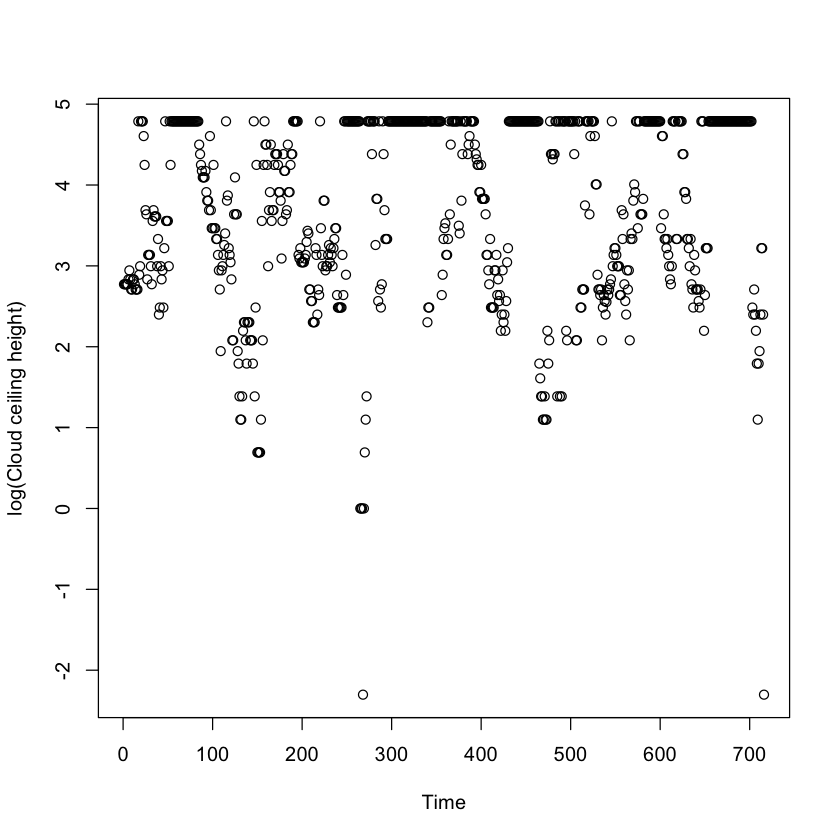

In [27]:
library(mvtnorm)
load(url("https://www.math.ntnu.no/emner/TMA4300/2026v/clouds.RData"))     
par(bg="white")
plot(clouds$z, xlab="Time", ylab="log(Cloud ceiling height)")

In [ ]:
metropolis_hastings <- function(y, n_iter){
    n <- length(y)
    y1 <- y[1]
    y2n <- y[-1]
    
    # Caluculating some useful terms
    X <- cbind(1, y[-n])
    Q <- t(X) %*% X
    Q_inv <- solve(Q)
    beta_hat <- Q_inv %*% t(X) %*% y2n
    e_hat <- y2n - X %*% beta_hat
    SSR <- sum(e_hat^2)

    # Log-function to find the correction term in the posterior
    # Used twice on previous and new betas and tau and used 
    # to calculate acceptence
    log_h <- function(beta, tau, y1) {
        b0 <- beta[1]
        b1 <- beta[2]
        
        if (tau <= 0 || b1 <= -1 || b1 >= 1) return(-Inf)
        
        0.5 * log((1 + b1) / (1 - b1)) - 0.5 * tau * (1 - b1^2) * (y1 - b0 / (1 - b1))^2
    }

    # Funciton to draw the proposal values of tau and beta. Beta depends on tau.
    # These are the draws from the distributions as defined in previous task
    draw_prop <- function(){
        tau_prop  <- rgamma(1, shape = (n-2) / 2, rate = SSR / 2)
        beta_prop <- as.numeric(rmvnorm(1, mean = beta_hat, sigma = Q_inv / tau_prop))
        list(beta = beta_prop, tau = tau_prop)
    }


    # Just to find initial values for beta and tau
    repeat{
        prop <- draw_prop()
        if (is.finite(log_h(prop$beta, prop$tau, y1))){
            beta_curr <- prop$beta
            tau_curr  <- prop$tau
            break
        }
    }

    beta_save <- matrix(NA_real_, n_iter, 2)
    tau_save <- numeric(n_iter)
    beta_save[1, ] <- beta_curr
    tau_save[1] <- tau_curr

    n_accepted <- 0

    # Actual M-H-algorithm:
    for (i in 2:n_iter){
        prop <- draw_prop()
        log_alpha <- log_h(prop$beta, prop$tau, y1) - log_h(beta_curr, tau_curr, y1)

        u <- runif(1)
        if (log(u) < log_alpha){
            beta_curr <- prop$beta
            tau_curr <- prop$tau
            n_accepted <- n_accepted + 1
        }
        beta_save[i,] <- beta_curr
        tau_save[i] <- tau_curr

    }
    list(acc_rate = n_accepted / n_iter, beta = beta_save, tau = tau_save)
}



In [57]:
y <- clouds$z
fit <- metropolis_hastings(y, 1000)
cat("Acceptence rate of Metropolis-Hastings is: ", fit$acc_rate)

Acceptence rate of Metropolis-Hastings is:  0.928

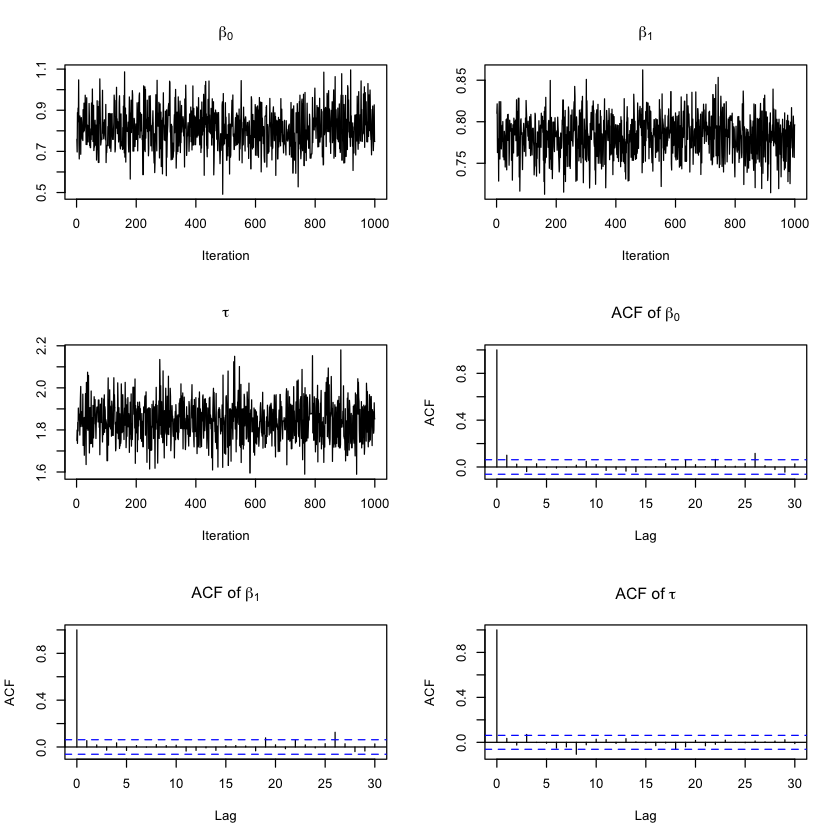

In [53]:
par(mfrow = c(3,2), bg = "white")

plot(fit$beta[,1], type = "l", main = expression(beta[0]), ylab = "", xlab = "Iteration")
plot(fit$beta[,2], type = "l", main = expression(beta[1]), ylab = "", xlab = "Iteration")
plot(fit$tau,      type = "l", main = expression(tau),      ylab = "", xlab = "Iteration")

acf(fit$beta[,1], main = expression("ACF of " * beta[0]))
acf(fit$beta[,2], main = expression("ACF of " * beta[1]))
acf(fit$tau,      main = expression("ACF of " * tau))

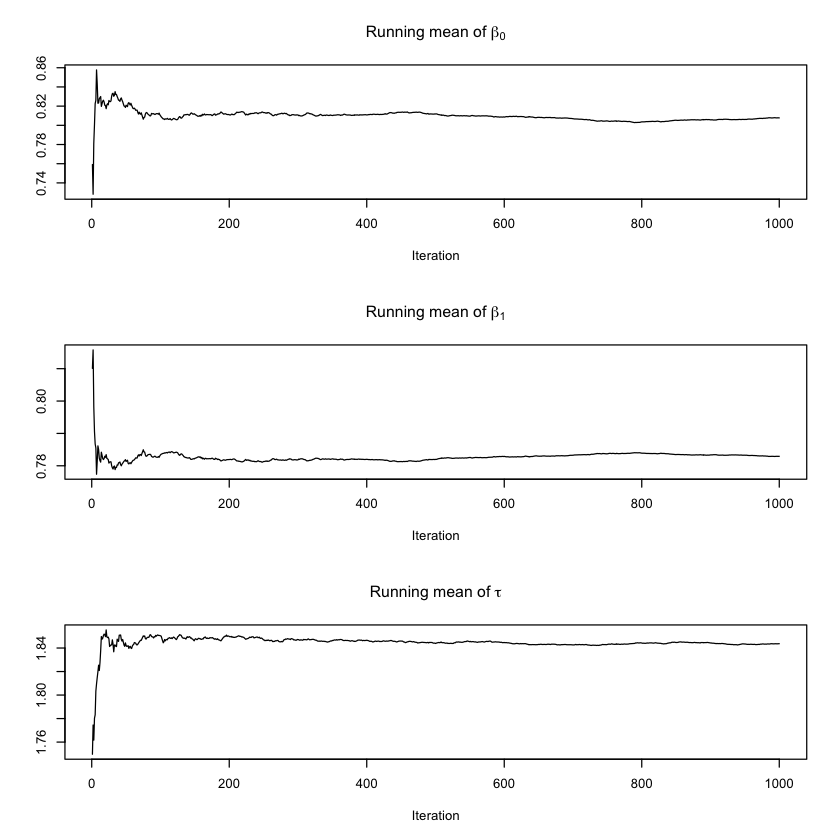

In [54]:
par(mfrow = c(3,1), bg = "white")

plot(cumsum(fit$beta[,1]) / seq_along(fit$beta[,1]), type = "l",
     main = expression("Running mean of " * beta[0]), ylab = "", xlab = "Iteration")

plot(cumsum(fit$beta[,2]) / seq_along(fit$beta[,2]), type = "l",
     main = expression("Running mean of " * beta[1]), ylab = "", xlab = "Iteration")

plot(cumsum(fit$tau) / seq_along(fit$tau), type = "l",
     main = expression("Running mean of " * tau), ylab = "", xlab = "Iteration")

#### Discussions:

From 1000 iterations that the acceptence rating of the algorithm is ~0.928. Further increasing number of iterations also about the same acceptance rate. This is a high acceptence rate, and is really close to the true posterior. Thus we are happy with $(*)$ as a choice of proposal.

---

### Part f) Adding censoring to observations

Let $\mathbf y_{-j}$ denote the subvector obtained by removing $y_j$ from $\mathbf y$ and let $\mathbf \delta = (\delta_1, \delta_2, \dots, \delta_n)$ denote the censoring indicators. 

From the hint, we have
$$
\begin{pmatrix}
y_{j-1}\\
y_j\\
y_{j+1}
\end{pmatrix}
\sim
\mathcal N\!\left(
\mu \mathbf 1,\;
\tau^{-1}
\begin{pmatrix}
1 & -\phi & 0\\
-\phi & 1+\phi^2 & -\phi\\
0 & -\phi & 1
\end{pmatrix}^{-1}
\right).
$$
Equivalently, the corresponding precision matrix is
$$
\tau
\begin{pmatrix}
1 & -\phi & 0\\
-\phi & 1+\phi^2 & -\phi\\
0 & -\phi & 1
\end{pmatrix}.
$$

Using standard results for the conditional distribution of a multivariate normal based on the precision matrix, the conditional precision of $y_j$ given $y_{j-1}$ and $y_{j+1}$ is
$$
\tau(1+\phi^2),
$$
so
$$
\operatorname{Var}(y_j \mid \mathbf y_{-j},\mathbf \beta,\tau)=\frac{\tau^{-1}}{1+\phi^2}.
$$

From the j-th row of the precision matrix,
$$
-\phi(y_{j-1}-\mu) + (1+\phi^2)(y_j-\mu) - \phi(y_{j+1}-\mu),
$$
which yields the conditional mean
$$
\mathbb E(y_j \mid y_{-j},\beta,\tau)
=
\mu+\frac{\phi}{1+\phi^2}(y_{j-1}+y_{j+1}-2\mu).
$$

Hence,
$$
\boxed{
y_j \mid \mathbf y_{-j},\mathbf \beta,\tau
\sim
\mathcal N\!\left(
\mu+\frac{\phi}{1+\phi^2}(y_{j-1}+y_{j+1}-2\mu),\;
\frac{\tau^{-1}}{1+\phi^2}
\right).
}
$$


Now incorporate the censoring information $(\delta,z)$. By definition,
$$
\delta_j=
\begin{cases}
1, & \text{if } y_j=z_j \ (\text{observed}),\\
0, & \text{if } y_j>z_j \ (\text{right-censored}).
\end{cases}
$$

Define
$$
m_j=\mu+\frac{\phi}{1+\phi^2}(y_{j-1}+y_{j+1}-2\mu),
\qquad
\sigma_j^2=\frac{\tau^{-1}}{1+\phi^2}.
$$

Then the conditional density becomes
$$
y_j \mid \mathbf y_{-j},\mathbf \delta,\mathbf z,\mathbf \beta,\tau =
\begin{cases}
\delta_{z_j}(y_j), & \delta_j=1,\\[1ex]
\mathcal N(m_j,\sigma_j^2)\ \text{truncated to }(z_j,\infty), & \delta_j=0.
\end{cases}
$$

More explicitly, for $\delta_j=0$,
$$
f(y_j \mid \mathbf y_{-j},\mathbf \delta,\mathbf z,\mathbf \beta,\tau)
=
\frac{
\frac{1}{\sigma_j}\,\varphi\!\left(\frac{y_j-m_j}{\sigma_j}\right)
}{
1-\Phi\!\left(\frac{z_j-m_j}{\sigma_j}\right)
}

\, I(y_j>z_j),
$$
where $\varphi(\cdot)$ and $\Phi(\cdot)$ denote the standard normal density and distribution functions.

---

### Part g) Gibbs sampling for $\mathbf \beta$ and $\tau$


In [ ]:
library(coda)
library(truncnorm)

gibbs_sampler <- function(z, delta, n_iter = 1000, burn = 200, thin = 1) {
    n <- length(z)
    
    y <- z
    y[delta == 0] <- z[delta == 0] + 0.1
    
    # Storage
    beta0_save <- numeric(n_iter)
    beta1_save <- numeric(n_iter)
    tau_save   <- numeric(n_iter)
    ycens_save <- matrix(NA_real_, nrow = n_iter, ncol = sum(delta == 0))
    cens_idx  <- which(delta == 0)
    
    for (iter in 1:n_iter) {
        
        y2n <- y[-1]
        X <- cbind(1, y[-n])
        
        Q <- t(Q) %*% Q
        Q_inv <- solve(Q)
        beta_hat <- as.numeric(Q_inv %*% crossprod(X, y2n))
        e_hat <- as.numeric(y2n - X %*% beta_hat)
        SSR <- sum(e_hat^2)
        
        # tau | y ~ Gamma((n-2)/2, SSR/2)
        tau <- rgamma(1, shape = (n - 2) / 2, rate = SSR / 2)
        
        # beta | tau, y ~ N(beta_hat, (tau Q)^(-1))
        beta <- as.numeric(rmvnorm(1, mean = beta_hat, sigma = Q_inv / tau))
        beta0 <- beta[1]
        beta1 <- beta[2]
        
        # convert to (mu, phi)
        phi <- beta1
        
        # avoid illegal values; reject by redraw if outside stationarity
        while (phi <= -1 || phi >= 1) {
            tau <- rgamma(1, shape = (n - 2) / 2, rate = SSR / 2)
            beta <- as.numeric(rmvnorm(1, mean = beta_hat, sigma = Q_inv / tau))
            beta0 <- beta[1]
            beta1 <- beta[2]
            phi <- beta1
        }
        
        mu <- beta0 / (1 - beta1)
        
        ## --- Step 2: update each censored y_j given the rest ---
        for (j in cens_idx) {
            
            if (j == 1) {
                # y1 | y2, mu, phi, tau
                m  <- mu + phi * (y[2] - mu)
                s2 <- 1 / tau
                y[1] <- rtruncnorm(1, a = z[1], b = Inf, mean = m, sd = sqrt(s2))
              
            } else if (j == n) {
                # yn | y_{n-1}, mu, phi, tau
                m  <- mu + phi * (y[n - 1] - mu)
                s2 <- 1 / tau
                y[n] <- rtruncnorm(1, a = z[n], b = Inf, mean = m, sd = sqrt(s2))
              
            } else {
                # interior point:
                # y_j | y_{-j}, beta, tau ~ N(m_j, tau^{-1}/(1+phi^2)) truncated to (z_j, Inf)
                m  <- mu + (phi / (1 + phi^2)) * (y[j - 1] + y[j + 1] - 2 * mu)
                s2 <- 1 / (tau * (1 + phi^2))
                y[j] <- rtruncnorm(1, a = z[j], b = Inf, mean = m, sd = sqrt(s2))
            }
        }
        
        beta0_save[iter] <- beta0
        beta1_save[iter] <- beta1
        tau_save[iter]   <- tau
        ycens_save[iter, ] <- y[cens_idx]
    }
    
    # Build mcmc object
    keep <- seq(burn + 1, n_iter, by = thin)
    
    chain_mat <- cbind(
        beta0 = beta0_save[keep],
        beta1 = beta1_save[keep],
        tau   = tau_save[keep],
        ycens_save[keep, , drop = FALSE]
    )
    
    if (length(cens_idx) > 0) {
        colnames(chain_mat)[4:ncol(chain_mat)] <- paste0("y[", cens_idx, "]")
    }
    
    mcmc(chain_mat)
}

In [78]:
load(url("https://www.math.ntnu.no/emner/TMA4300/2026v/clouds.RData"))

z <- clouds$z
delta <- clouds$delta

fit_gibbs <- gibbs_sampler(z, delta, n_iter = 4000, burn = 1000, thin = 5)
fit_gibbs

Markov Chain Monte Carlo (MCMC) output:
Start = 1 
End = 600 
Thinning interval = 1 
           beta0     beta1       tau    y[17]    y[20]    y[21]    y[22]
  [1,] 0.5311578 0.8738998 0.9948989 4.868988 4.836142 5.903474 5.083684
  [2,] 0.7348271 0.8535289 1.0164368 5.032356 5.213198 5.688099 5.103278
  [3,] 0.4711988 0.8867934 0.9849114 4.812944 4.866932 5.191575 5.007999
  [4,] 0.4330719 0.8971644 0.9317874 4.796963 5.442499 5.783824 4.925471
  [5,] 0.3152425 0.9099882 0.9755605 5.114750 4.843659 5.064414 5.467260
  [6,] 0.5315998 0.8722668 0.9484743 4.890018 5.422579 5.224828 5.401195
  [7,] 0.4858038 0.8909766 0.9431557 4.881172 5.438821 5.371871 5.292158
  [8,] 0.4805771 0.8962085 0.8847267 4.892247 5.459239 7.948117 7.290019
  [9,] 0.3851918 0.9098969 1.0025161 5.165289 5.895820 5.667252 4.918611
 [10,] 0.5392119 0.8806865 0.9224710 5.023807 5.205975 7.012451 6.255067
 [11,] 0.4524736 0.9004709 0.8262013 5.035706 4.898641 5.616772 5.208560
 [12,] 0.4872991 0.8907489 0.9647470 4.

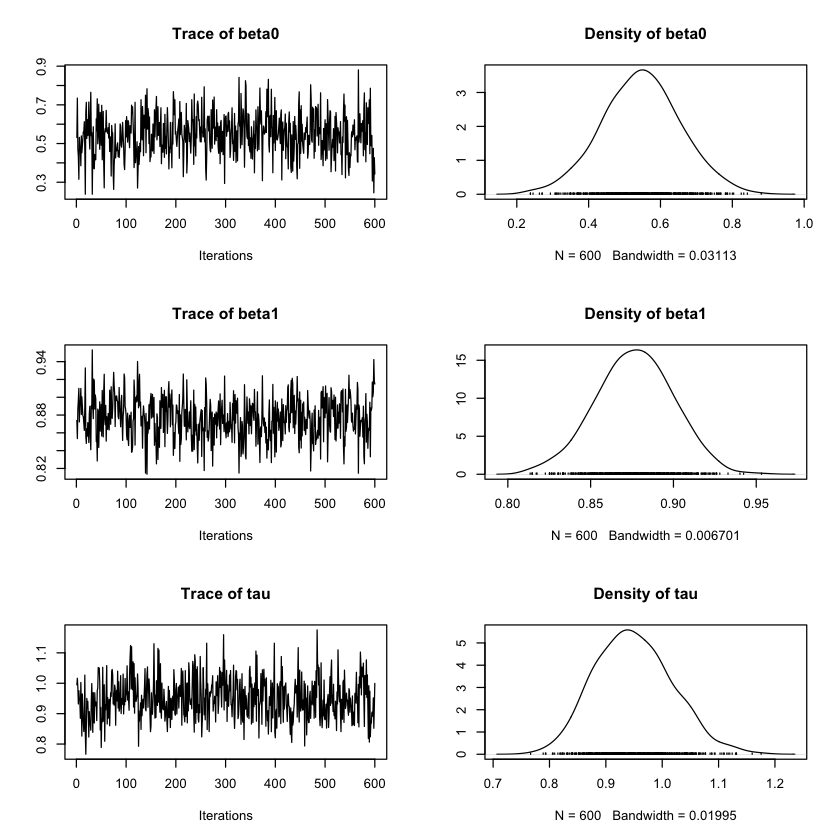

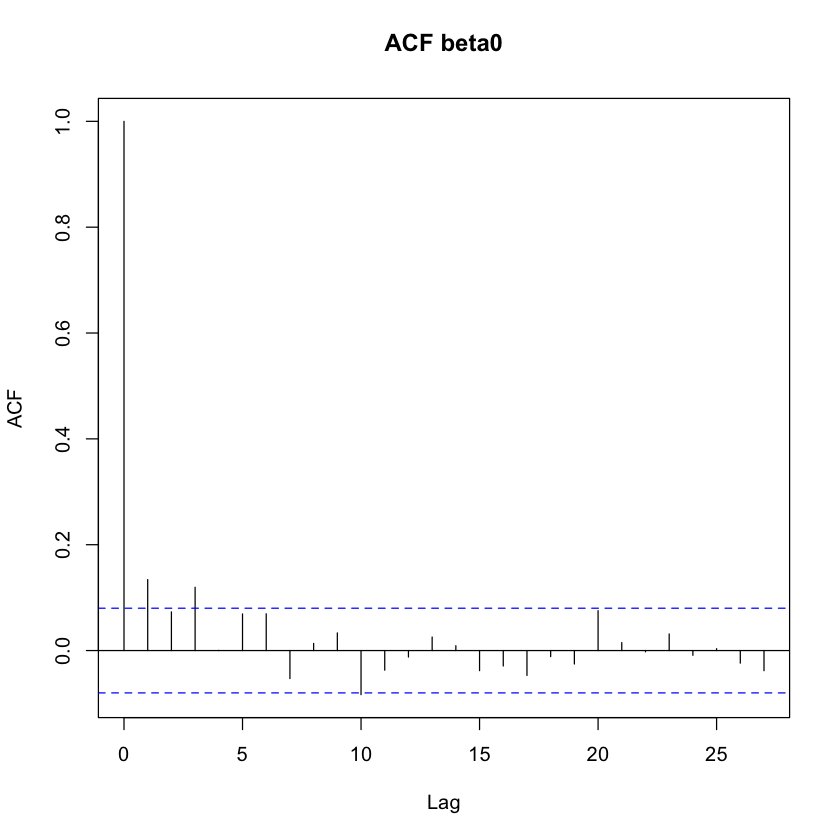

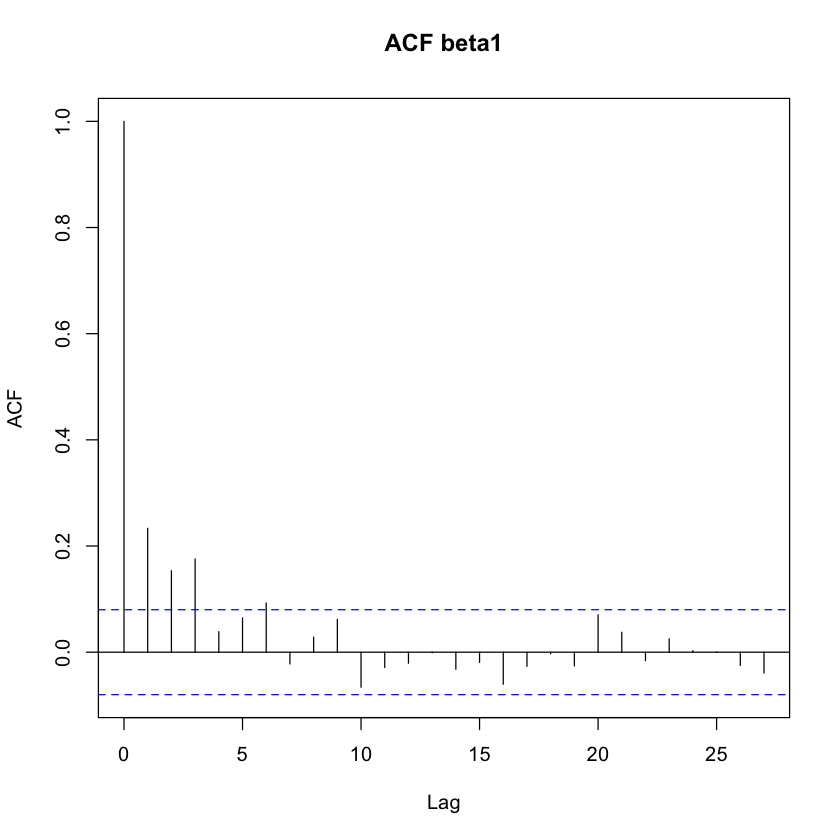

beta0    beta1      tau 
329.9692 232.6909 249.7262


Iterations = 1:600
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 600 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

        Mean      SD  Naive SE Time-series SE
beta0 0.5470 0.10843 0.0044268       0.005969
beta1 0.8765 0.02326 0.0009494       0.001525
tau   0.9495 0.06764 0.0027615       0.004280

2. Quantiles for each variable:

        2.5%    25%    50%    75%  97.5%
beta0 0.3320 0.4745 0.5475 0.6159 0.7623
beta1 0.8284 0.8615 0.8771 0.8920 0.9213
tau   0.8300 0.8998 0.9454 0.9935 1.0882


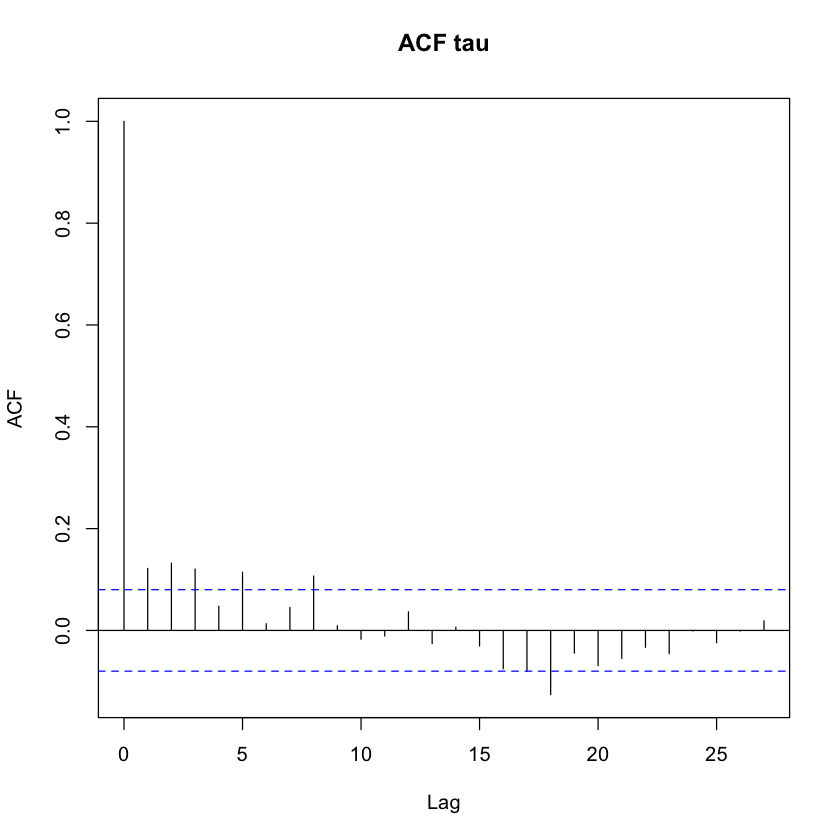

In [79]:
par(bg = "white")
plot(fit_gibbs[, c("beta0", "beta1", "tau")])

acf(as.numeric(fit_gibbs[, "beta0"]), main = "ACF beta0")
acf(as.numeric(fit_gibbs[, "beta1"]), main = "ACF beta1")
acf(as.numeric(fit_gibbs[, "tau"]),   main = "ACF tau")

effectiveSize(fit_gibbs[, c("beta0", "beta1", "tau")])
summary(fit_gibbs[, c("beta0", "beta1", "tau")])

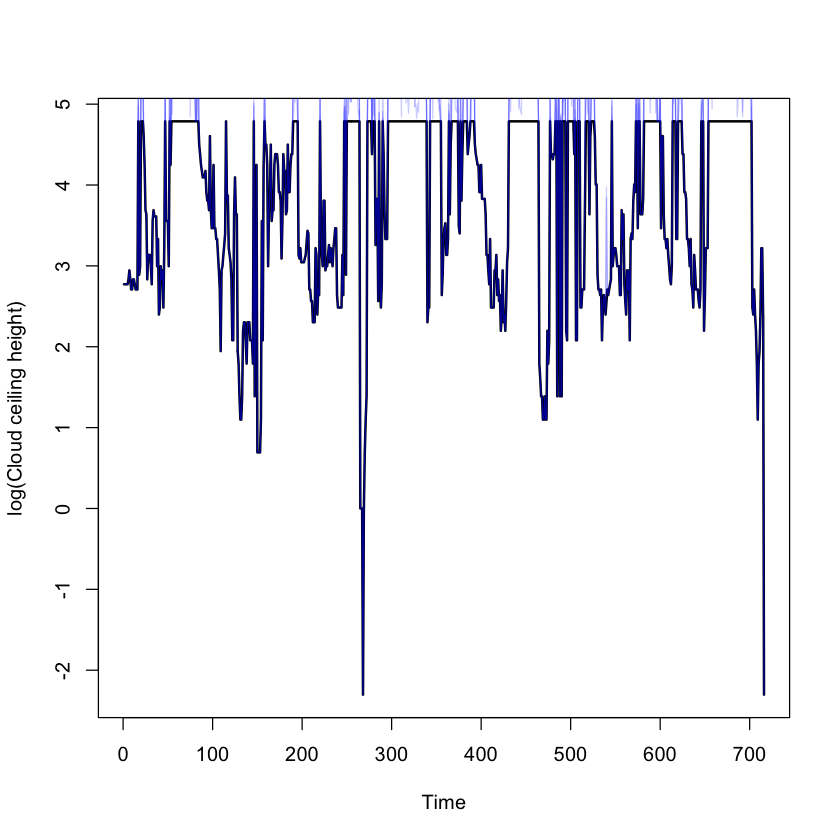

In [81]:
cens_idx <- which(delta == 0)

par(bg = "white")
plot(z, type = "l", lwd = 2, xlab = "Time", ylab = "log(Cloud ceiling height)")
for (k in c(100, 200, 400, 600)) {
  y_draw <- z
  y_draw[cens_idx] <- as.numeric(fit_gibbs[k, paste0("y[", cens_idx, "]")])
  lines(y_draw, col = rgb(0, 0, 1, 0.2))
}

#### Discussions:

We see from the traceplots that the simulated parametrevalues varies greatly and "evenly". The densities support the same interpretation. We observe from the autocorrelation plots for the different parameters that there are some small lags, with most for $\beta_1$. However, this decays very quickly. 

From the plot of all of $\mathbf y$ we see a clear resembleness to the original plot for the problem (absolute first plot of the task). We see that the censored values are filled in above the limit and are influenced by the close uncensored values. 

$\beta_1=\phi$ is found to be ~0.88 which is fairly close to 1, which means that neighboring values are relatively related to each other. This corralation decreases the speed of the Gibbs sampler. 


By accounting for censoring, we allow values to exceed the set detection limit (4.79). This leads to more realistic cloud trajectories, as clouds are still high up in the sky even though we can't detect them:) If we only look at treat the observed data, we might see a reduced bias and better accuracy towards our data, but again we won't be including higher clouds.

---

## Problem 4

### Part a) Non-identifiability of the theta-logistic model

We want to show that the model specified by (1) and (2) is non identifiable, meaning that different parameter values lead to the same distribution of the observed data $\mathbf{y}$.

#### Setup

The model is:
$$u_t = u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right) + e_t, \qquad e_t \sim N(0, \sigma) \tag{1}$$
$$y_t \sim \text{Poisson}(c\, e^{u_t}) \tag{2}$$

with parameters $\boldsymbol{\theta} = (r, K, \theta, \sigma, c)$ and latent states $\mathbf{u} = (u_1, \ldots, u_n)$.

#### Showing non-identifiability

Consider shifting all latent states by a constant $\delta \in \mathbb{R}$:

$$v_t = u_t + \delta$$

Substituting $u_t = v_t - \delta$ and $u_{t-1} = v_{t-1} - \delta$ into (1):

$$v_t - \delta = (v_{t-1} - \delta) + r\left(1 - \left(\frac{e^{v_{t-1} - \delta}}{K}\right)^\theta\right) + e_t$$

$$v_t = v_{t-1} + r\left(1 - \left(\frac{e^{v_{t-1}}}{K e^{\delta}}\right)^\theta\right) + e_t$$

Define $K' = K e^{\delta}$. Then:

$$v_t = v_{t-1} + r\left(1 - \left(\frac{e^{v_{t-1}}}{K'}\right)^\theta\right) + e_t$$

This has exactly the same form as the original state equation (1), but with $K$ replaced by $K' = K e^{\delta}$.

Substituting $u_t = v_t - \delta$ into (2):

$$y_t \sim \text{Poisson}(c\, e^{u_t}) = \text{Poisson}(c\, e^{v_t - \delta}) = \text{Poisson}(c\, e^{-\delta}\, e^{v_t})$$

Define $c' = c\, e^{-\delta}$. Then:

$$y_t \sim \text{Poisson}(c'\, e^{v_t})$$

This has exactly the same form as the original observation equation (2), but with $c$ replaced by $c' = c\, e^{-\delta}$.

The transformed model with parameters $(r, K', \theta, \sigma, c')$ and latent states $\mathbf{v}$ produces exactly the same distribution over observations $\mathbf{y}$ as the original model with parameters $(r, K, \theta, \sigma, c)$ and latent states $\mathbf{u}$. Since $\delta$ is arbitrary, infinitely many parameter combinations give the same likelihood. Therefore, the model is non identifiable: the parameters $c$ and $K$ cannot be estimated simultaneously.

Note that $c' \cdot K'^\theta = c\,e^{-\delta} \cdot (K\,e^{\delta})^\theta$ depends on $\delta$ unless $\theta = 1$, but the key point is that $c' \cdot (K')^0 \neq c \cdot K^0$ in general. The non-identifiability arises because a shift in the latent process can always be absorbed by jointly rescaling $c$ and $K$.

#### Making the model identifiable

To make the model identifiable without changing the model space, we fix $c = 1$. This is equivalent to absorbing the sampling effort into the latent states by redefining $u_t \leftarrow u_t + \ln c$, so that:

$$y_t \sim \text{Poisson}(e^{u_t})$$

With $c$ fixed, the shift $\delta$ is no longer a free parameter (since changing $\delta$ would require changing $c$), and $(r, K, \theta, \sigma)$ become identifiable. $\square$

---

### Part b) Laplace approximation with RTMB

We fix $c = 1$ for identifiability (from part a). The joint density $f(\mathbf{y}, \mathbf{u} | \boldsymbol{\theta})$ consists of:

1. **Prior on $u_1$:** $\pi(u_1) \propto 1$ (improper uniform), contributes no terms.
2. **State transitions** ($t = 2, \ldots, n$): $u_t | u_{t-1} \sim N\left(u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right),\; \sigma^2\right)$
3. **Observations** ($t = 1, \ldots, n$): $y_t \sim \text{Poisson}(e^{u_t})$

The negative log joint density is therefore:

$$-\log f(\mathbf{y}, \mathbf{u} | \boldsymbol{\theta}) = -\sum_{t=2}^{n} \log\phi\!\left(\frac{u_t - \mu_t}{\sigma}\right) + n\log\sigma - \sum_{t=1}^{n}\left(y_t u_t - e^{u_t} - \log(y_t!)\right)$$

where $\mu_t = u_{t-1} + r\left(1 - \left(\frac{e^{u_{t-1}}}{K}\right)^\theta\right)$ and $\phi$ is the standard normal density.

To handle parameter constraints, we pass logarithms of constrained parameters: $\log K$, $\log\theta$, $\log\sigma$.

In [ ]:
install.packages("RTMB")
library(RTMB)

# Load the data
load(url("https://www.math.ntnu.no/emner/TMA4300/2026v/theta-logistic.RData"))
cat("Number of observations:", length(y), "\n")
par(bg = "white")
plot(y, type = "l", xlab = "Time", ylab = "Count", main = "Observed counts y_t")

In [ ]:
# Define the negative log joint density for RTMB
f <- function(parms) {
  getAll(parms, data)
  
  r0 <- exp(logr0)
  theta <- exp(logtheta)
  K <- exp(logK)
  sigma <- exp(logsigma)
  
  y <- OBS(y)
  
  n <- length(u)
  nll <- 0
  
  # State transitions: u_t | u_{t-1} ~ N(mu_t, sigma^2)
  for (t in 2:n) {
    m <- u[t-1] + r0 * (1.0 - (exp(u[t-1]) / K)^theta)
    nll <- nll - dnorm(u[t], m, sigma, log = TRUE)
  }
  
  # Observations: y_t ~ Poisson(exp(u_t))
  for (t in 1:n) {
    nll <- nll - dpois(y[t], lambda = exp(u[t]), log = TRUE)
  }
  
  ADREPORT(r0)
  ADREPORT(K)
  ADREPORT(theta)
  ADREPORT(sigma)
  
  return(nll)
}

# Data and initial parameters
data <- list(y = y)
n <- length(y)

parameters <- list(
  logr0 = log(0.1),
  logtheta = log(1),
  logK = log(mean(y)),
  logsigma = log(0.3),
  u = rep(log(mean(y)), n)
)

# Create objective function with Laplace approximation over u
obj <- MakeADFun(f, parameters, random = "u", silent = TRUE)

### Part c) Maximise the Laplace approximation

We optimise the Laplace-approximated marginal likelihood using `nlminb` and examine the estimated parameters and latent states.

In [ ]:
# Maximize the Laplace approximation of the marginal likelihood
opt <- nlminb(obj$par, obj$fn, obj$gr,
              control = list(eval.max = 5000, iter.max = 2000))

cat("Convergence:", opt$convergence, "(0 = success)\n")
cat("Objective:", opt$objective, "\n\n")

# Parameter estimates and standard errors
sdr <- sdreport(obj)
cat("Fixed parameters (log scale):\n")
print(summary(sdr, "fixed"))
cat("\nTransformed parameters (original scale):\n")
print(summary(sdr, "report"))

In [ ]:
# Extract estimated latent states
u_hat <- summary(sdr, "random")[, "Estimate"]
u_se <- summary(sdr, "random")[, "Std. Error"]

par(bg = "white", mfrow = c(2, 1))
options(repr.plot.width = 14, repr.plot.height = 10)

# Plot u_t estimates with confidence bands
plot(u_hat, type = "l", col = "blue", lwd = 2,
     xlab = "Time", ylab = expression(u[t]),
     main = expression("Estimated latent log-density " * u[t]))
polygon(c(1:n, n:1),
        c(u_hat + 1.96 * u_se, rev(u_hat - 1.96 * u_se)),
        col = rgb(0, 0, 1, 0.2), border = NA)
lines(u_hat, col = "blue", lwd = 2)

# Plot exp(u_t) vs observed counts y_t
plot(y, type = "p", pch = 16, col = "grey40", cex = 0.8,
     xlab = "Time", ylab = "Population density",
     main = expression("Estimated " * e^{u[t]} * " vs observed counts " * y[t]))
lines(exp(u_hat), col = "red", lwd = 2)
legend("topright", legend = c("Observed y_t", expression(e^{hat(u)[t]})),
       col = c("grey40", "red"), pch = c(16, NA), lwd = c(NA, 2))

The optimization converges successfully. The estimated parameters on the original scale are:

| Parameter | Estimate | Std. Error | Interpretation |
|-----------|----------|------------|----------------|
| $r$ | 0.090 | 0.033 | Slow population growth rate at low density |
| $K$ | 44.2 | 8.3 | Carrying capacity consistent with median observed count of 20 |
| $\theta$ | 1.88 | 0.36 | Super-linear density dependence ($\theta > 1$) |
| $\sigma$ | 0.33 | 0.026 | Moderate process noise |

The plots show that the estimated latent trajectory $e^{\hat{u}_t}$ smoothly tracks the observed counts $y_t$. The confidence bands on $u_t$ are narrow in the middle of the time series and wider at the endpoints.

---

### Part d) Simulation study

We write a function to simulate synthetic data from the theta-logistic model, fit the model to several realisations, and compare estimation errors to the standard errors reported by `sdreport`.

The standard errors from `sdreport` are based on the delta method: for the fixed parameters, they come from the inverse of the Hessian of the Laplace approximated marginal negative log-likelihood at the optimum. For reported (transformed) parameters, the delta method is applied to propagate uncertainty through the transformation. These are asymptotic standard errors based on a normal approximation to the sampling distribution of the MLE.

In [ ]:
# Function to simulate from the theta-logistic model
simulate_theta_logistic <- function(n, r0, K, theta, sigma, u1) {
  u <- numeric(n)
  u[1] <- u1
  
  for (t in 2:n) {
    mu_t <- u[t-1] + r0 * (1 - (exp(u[t-1]) / K)^theta)
    u[t] <- rnorm(1, mean = mu_t, sd = sigma)
  }
  
  # Observations with c = 1
  y_sim <- rpois(n, lambda = exp(u))
  
  return(list(y = y_sim, u = u))
}

# Use estimated parameters from the real data as "true" values
true_r0 <- exp(opt$par["logr0"])
true_K <- exp(opt$par["logK"])
true_theta <- exp(opt$par["logtheta"])
true_sigma <- exp(opt$par["logsigma"])

cat("True parameters for simulation:\n")
cat("  r0 =", true_r0, "\n")
cat("  K =", true_K, "\n")
cat("  theta =", true_theta, "\n")
cat("  sigma =", true_sigma, "\n")

In [ ]:
# Simulation study: fit model to multiple synthetic datasets
set.seed(123)
n_sim <- 20
n_obs <- length(y)

# True values on log scale
true_fixed <- opt$par

# Define a new function for simulation that takes data as argument
f_sim <- function(parms) {
  getAll(parms, sim_data)
  
  r0 <- exp(logr0)
  theta <- exp(logtheta)
  K <- exp(logK)
  sigma <- exp(logsigma)
  
  y <- OBS(y)
  
  n <- length(u)
  nll <- 0
  
  for (t in 2:n) {
    m <- u[t-1] + r0 * (1.0 - (exp(u[t-1]) / K)^theta)
    nll <- nll - dnorm(u[t], m, sigma, log = TRUE)
  }
  
  for (t in 1:n) {
    nll <- nll - dpois(y[t], lambda = exp(u[t]), log = TRUE)
  }
  
  return(nll)
}

# Storage for estimates and standard errors
est_fixed <- matrix(NA, nrow = n_sim, ncol = 4)
se_fixed <- matrix(NA, nrow = n_sim, ncol = 4)
colnames(est_fixed) <- colnames(se_fixed) <- names(opt$par)

for (s in 1:n_sim) {
  # Simulate data
  sim <- simulate_theta_logistic(n_obs, true_r0, true_K, true_theta, true_sigma, u1 = u_hat[1])
  
  # Set sim_data in the environment where f_sim can see it
  sim_data <- list(y = sim$y)
  
  parms_sim <- list(
    logr0 = log(0.1),
    logtheta = log(1),
    logK = log(mean(sim$y) + 1),
    logsigma = log(0.3),
    u = rep(log(mean(sim$y) + 1), n_obs)
  )
  
  obj_sim <- tryCatch(
    MakeADFun(f_sim, parms_sim, random = "u", silent = TRUE),
    error = function(e) NULL
  )
  if (is.null(obj_sim)) next
  
  opt_sim <- tryCatch(
    nlminb(obj_sim$par, obj_sim$fn, obj_sim$gr,
           control = list(eval.max = 5000, iter.max = 2000)),
    error = function(e) NULL
  )
  if (is.null(opt_sim) || opt_sim$convergence != 0) next
  
  sdr_sim <- tryCatch(sdreport(obj_sim), error = function(e) NULL)
  if (is.null(sdr_sim)) next
  
  fixed_summary <- summary(sdr_sim, "fixed")
  est_fixed[s, ] <- fixed_summary[, "Estimate"]
  se_fixed[s, ] <- fixed_summary[, "Std. Error"]
  
  cat("Simulation", s, "done. Convergence:", opt_sim$convergence, "\n")
}

cat("\nSuccessful fits:", sum(!is.na(est_fixed[, 1])), "out of", n_sim, "\n")

In [ ]:
# Compare estimation errors to reported standard errors
valid <- !is.na(est_fixed[, 1])

# Handle NaN in se_fixed for the mean: use na.rm
errors <- sweep(est_fixed[valid, ], 2, true_fixed)
mean_se <- colMeans(se_fixed[valid, ], na.rm = TRUE)
empirical_sd <- apply(errors, 2, sd)

comparison <- data.frame(
  Parameter = names(opt$par),
  True_value = as.numeric(true_fixed),
  Mean_estimate = colMeans(est_fixed[valid, ]),
  Mean_bias = colMeans(errors),
  Empirical_SD = empirical_sd,
  Mean_reported_SE = mean_se,
  Ratio_EmpSD_SE = empirical_sd / mean_se
)
rownames(comparison) <- NULL
print(comparison)

**Comments on part d) ,  Simulation study:**

All 20 simulations converged. The results are:

- $\log K$ and $\log\sigma$ have `Ratio_EmpSD_SE` close to 1 (1.19 and 0.91 respectively), meaning the standard errors reported by `sdreport` accurately reflect the true variability. The Laplace approximation works well for these parameters.

- $\log r_0$ and $\log\theta$ show much larger empirical variability than the reported standard errors, and one simulation produced NaN standard errors. This reflects a well-known property of the theta-logistic model: $r$ and $\theta$ are poorly identified because they trade off against each other,  many combinations of $(r, \theta)$ produce similar dynamics. The large empirical SD (4.1 and 4.3) confirms this near-non-identifiability.

- Bias is negligible for $\log K$ and $\log\sigma$ ($<0.06$), but substantial for $\log r_0$ and $\log\theta$,  again reflecting their poor identifiability.

Theory behind `sdreport` standard errors: The standard errors are based on the delta method applied to the Laplace-approximated marginal likelihood. For the fixed parameters $\boldsymbol{\theta}$, the covariance matrix is estimated as the inverse of the Hessian of the negative log marginal likelihood at the optimum: $\text{Cov}(\hat{\boldsymbol{\theta}}) \approx \mathcal{H}^{-1}$. For back-transformed parameters reported via `ADREPORT` (e.g., $K = e^{\log K}$), the delta method propagates the uncertainty: $\text{Var}(g(\hat\theta)) \approx g'(\hat\theta)^2 \text{Var}(\hat\theta)$. This is an asymptotic normal approximation that assumes the likelihood is approximately quadratic near the optimum, an assumption that may not hold well for poorly identified parameters like $r$ and $\theta$.